<a href="https://colab.research.google.com/github/saatour/GW170817/blob/main/GW190814_draw_90pc_probability_contour_05032026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import sys, subprocess

subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "--upgrade",
                       "astropy", "astropy-healpix"])

0

In [2]:
import numpy as np, astropy
print("numpy:", np.__version__)
print("astropy:", astropy.__version__)

numpy: 2.0.2
astropy: 7.2.0


In [3]:
import numpy as np
import os, inspect
print("numpy version:", np.__version__)
print("numpy file:", inspect.getfile(np))
print("has in1d:", hasattr(np, "in1d"))
print("cwd:", os.getcwd())

numpy version: 2.0.2
numpy file: /usr/local/lib/python3.12/dist-packages/numpy/__init__.py
has in1d: True
cwd: /content


Skymap exists: True
Columns: ['PROB', 'DISTMU', 'DISTSIGMA', 'DISTNORM']
Detected raster sky map: NSIDE=1024, ORDERING=NESTED
Total prob: 1.0
Pixels in 90% region: 5642 mass: 0.9000003339167143


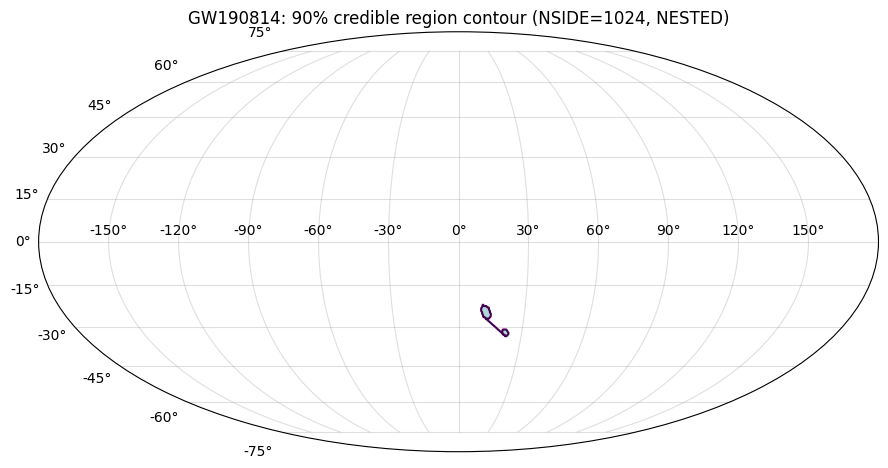

In [4]:
# ---------- Config ----------
SKYMAP_URL = "https://dcc.ligo.org/LIGO-P2000230/public/GW190814_skymap.fits.gz"
CREDIBLE = 0.90

# If the file is multi-order (UNIQ), we rasterize to this NSIDE:
TARGET_NSIDE_FOR_UNIQ = 256

# Plot grid resolution (higher = smoother contour, slower)
NGRID_LON = 720
NGRID_LAT = 360

FILL_REGION = True  # True = filled region + contour; False = contour only

# ---------- Imports (NO pip installs here) ----------
import os
import urllib.request
import numpy as np
import matplotlib.pyplot as plt

from astropy.table import Table
from astropy.io import fits
import astropy.units as u
from astropy_healpix import HEALPix, uniq_to_level_ipix


# ---------- Download ----------
fname = "GW190814_skymap.fits.gz"
if not os.path.exists(fname):
    urllib.request.urlretrieve(SKYMAP_URL, fname)

print("Skymap exists:", os.path.exists(fname))


# ---------- Read FITS header + table ----------
hdr = fits.getheader(fname, 1)  # extension 1 is usually the sky map table
t = Table.read(fname, hdu=1)
print("Columns:", t.colnames)

ordering = (hdr.get("ORDERING", "NESTED") or "NESTED").strip().upper()
if ordering not in ("NESTED", "RING"):
    print("Warning: Unknown ORDERING =", ordering, "-> assuming NESTED")
    ordering = "NESTED"

# astropy-healpix expects 'nested' or 'ring'
order_for_healpix = "nested" if ordering == "NESTED" else "ring"


# ---------- Case A: Raster HEALPix map (your file) ----------
# It has PROB and no UNIQ. PROB is probability *mass per pixel*.
if "UNIQ" not in t.colnames:
    if "PROB" not in t.colnames:
        raise KeyError("No UNIQ column and no PROB column found. Can't interpret this sky map.")

    nside = hdr.get("NSIDE", None)
    if nside is None:
        # Some files omit NSIDE keyword; infer from length if it's a full-sky HEALPix raster.
        npix = len(t["PROB"])
        # npix = 12 * nside^2  =>  nside = sqrt(npix/12)
        nside_guess = int(round(np.sqrt(npix / 12.0)))
        if 12 * nside_guess * nside_guess != npix:
            raise ValueError("Couldn't infer NSIDE from PROB length; header also missing NSIDE.")
        nside = nside_guess

    p = np.asarray(t["PROB"], dtype=float)
    # normalize (should already sum ~1, but be safe)
    tot = p.sum()
    if not np.isfinite(tot) or tot <= 0:
        raise RuntimeError("PROB column sums to non-finite or zero.")
    p = p / tot

    hp = HEALPix(nside=nside, order=order_for_healpix, frame="icrs")

    print(f"Detected raster sky map: NSIDE={nside}, ORDERING={ordering}")
    print("Total prob:", p.sum())

# ---------- Case B: Multi-order UNIQ map (fallback) ----------
else:
    uniq = np.asarray(t["UNIQ"])

    # Probability density per steradian column name variants
    probdens_col = None
    for c in ("PROBDENSITY", "PROB_DENSITY", "PROB_DENS"):
        if c in t.colnames:
            probdens_col = c
            break
    if probdens_col is None:
        raise KeyError("Found UNIQ but no probability-density column (PROBDENSITY / PROB_DENSITY / PROB_DENS).")

    probdens = np.asarray(t[probdens_col], dtype=float)  # 1/sr

    # Rasterize to fixed NSIDE in nested ordering (UNIQ is defined for nested)
    nside = TARGET_NSIDE_FOR_UNIQ
    target_level = int(np.log2(nside))
    if 2**target_level != nside:
        raise ValueError("TARGET_NSIDE_FOR_UNIQ must be a power of 2.")

    npix = 12 * nside * nside
    p = np.zeros(npix, dtype=float)

    level, ipix = uniq_to_level_ipix(uniq)
    level = np.asarray(level, dtype=int)
    ipix = np.asarray(ipix, dtype=np.int64)

    for L, I, pd in zip(level, ipix, probdens):
        nside_cell = 2**L
        area_cell = (4.0 * np.pi) / (12.0 * nside_cell * nside_cell)  # sr
        mass = pd * area_cell

        if L == target_level:
            if 0 <= I < npix:
                p[I] += mass
        elif L < target_level:
            d = target_level - L
            nchild = 4**d
            start = I * nchild
            end = start + nchild
            if start < npix:
                p[start:min(end, npix)] += mass / nchild
        else:
            d = L - target_level
            parent = I // (4**d)
            if 0 <= parent < npix:
                p[parent] += mass

    p /= p.sum()
    hp = HEALPix(nside=nside, order="nested", frame="icrs")
    print(f"Detected multi-order UNIQ sky map; rasterized to NSIDE={nside} (NESTED).")
    print("Total prob:", p.sum())


# ---------- 90% credible mask ----------
idx = np.argsort(p)[::-1]
cum = np.cumsum(p[idx])
k = np.searchsorted(cum, CREDIBLE, side="left")
k = min(k, len(idx) - 1)

mask = np.zeros_like(p, dtype=bool)
mask[idx[:k+1]] = True

print(f"Pixels in {int(CREDIBLE*100)}% region:", mask.sum(), "mass:", p[mask].sum())


# ---------- Contour plot (Mollweide) ----------
lon = np.linspace(-180, 180, NGRID_LON, endpoint=False) * u.deg
lat = np.linspace(-90, 90, NGRID_LAT) * u.deg
LON, LAT = np.meshgrid(lon, lat)

grid_pix = hp.lonlat_to_healpix(LON, LAT)
Z = mask[grid_pix].astype(float)

x = np.deg2rad(LON.to_value(u.deg))
y = np.deg2rad(LAT.to_value(u.deg))

fig = plt.figure(figsize=(9, 5.5))
ax = fig.add_subplot(111, projection="mollweide")

if FILL_REGION:
    ax.contourf(x, y, Z, levels=[0.5, 1.5], alpha=0.35)

ax.contour(x, y, Z, levels=[0.5], linewidths=1.5)

ax.grid(True, alpha=0.4)
ax.set_title(f"GW190814: {int(CREDIBLE*100)}% credible region contour (NSIDE={hp.nside}, {ordering})")
plt.tight_layout()
plt.show()

Skymap exists: True
Columns: ['PROB', 'DISTMU', 'DISTSIGMA', 'DISTNORM']
Detected raster sky map: NSIDE=1024, ORDERING=NESTED
Total prob: 1.0
Pixels in 90% region: 5642 mass: 0.9000003339167143


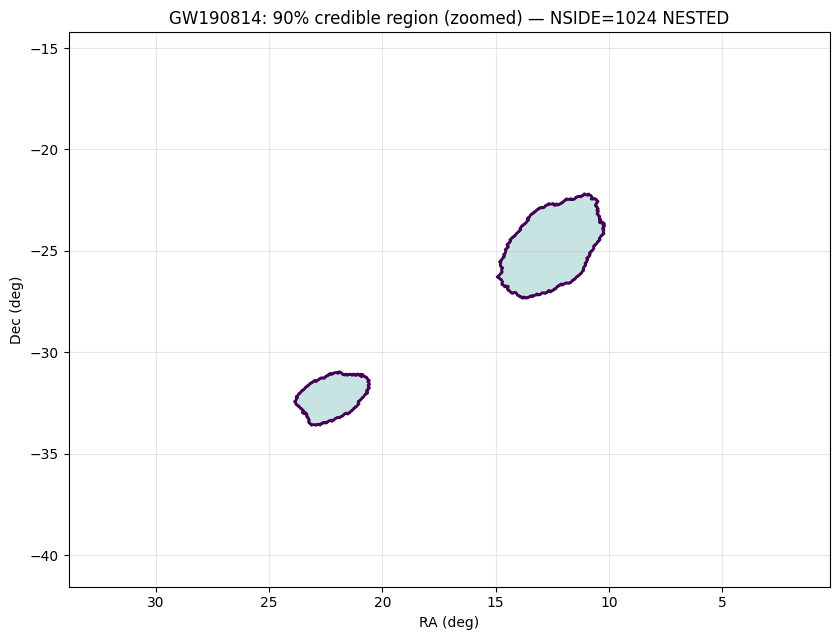

In [5]:
# ---------- Config ----------
SKYMAP_URL = "https://dcc.ligo.org/LIGO-P2000230/public/GW190814_skymap.fits.gz"
CREDIBLE = 0.90

# Plot grid resolution (higher = smoother contour, slower)
NGRID_RA = 900
NGRID_DEC = 450

FILL_REGION = True  # True = filled region + contour; False = contour only

# ---------- Imports (NO pip installs here) ----------
import os
import urllib.request
import numpy as np
import matplotlib.pyplot as plt

from astropy.table import Table
from astropy.io import fits
import astropy.units as u
from astropy_healpix import HEALPix


# ---------- Download ----------
fname = "GW190814_skymap.fits.gz"
if not os.path.exists(fname):
    urllib.request.urlretrieve(SKYMAP_URL, fname)

print("Skymap exists:", os.path.exists(fname))


# ---------- Read FITS header + table ----------
hdr = fits.getheader(fname, 1)          # extension 1 is usually the sky map table
t = Table.read(fname, hdu=1)
print("Columns:", t.colnames)

ordering = (hdr.get("ORDERING", "NESTED") or "NESTED").strip().upper()
order_for_healpix = "nested" if ordering == "NESTED" else "ring"

if "PROB" not in t.colnames:
    raise KeyError("This file doesn't have a PROB column; it's not the raster format expected here.")

nside = hdr.get("NSIDE", None)
if nside is None:
    # Infer NSIDE from number of pixels if header is missing it
    npix = len(t["PROB"])
    nside_guess = int(round(np.sqrt(npix / 12.0)))
    if 12 * nside_guess * nside_guess != npix:
        raise ValueError("Couldn't infer NSIDE from PROB length; header also missing NSIDE.")
    nside = nside_guess

p = np.asarray(t["PROB"], dtype=float)
p /= p.sum()  # normalize defensively

hp = HEALPix(nside=nside, order=order_for_healpix, frame="icrs")

print(f"Detected raster sky map: NSIDE={nside}, ORDERING={ordering}")
print("Total prob:", p.sum())


# ---------- 90% credible mask ----------
idx = np.argsort(p)[::-1]
cum = np.cumsum(p[idx])
k = np.searchsorted(cum, CREDIBLE, side="left")
k = min(k, len(idx) - 1)

mask = np.zeros_like(p, dtype=bool)
mask[idx[:k+1]] = True

print(f"Pixels in {int(CREDIBLE*100)}% region:", mask.sum(), "mass:", p[mask].sum())


# ---------- Zoomed RA/Dec plot ----------
mask_pix = np.where(mask)[0]
lon_c, lat_c = hp.healpix_to_lonlat(mask_pix)
ra_c = lon_c.to_value(u.deg)   # 0..360
dec_c = lat_c.to_value(u.deg)

def minimal_ra_window(ra_deg, pad_deg=10.0):
    """Smallest RA arc covering points (wrap-safe), returned as ra_min, ra_max in 0..360."""
    ra = np.mod(ra_deg, 360.0)
    ra_sorted = np.sort(ra)
    gaps = np.diff(np.r_[ra_sorted, ra_sorted[0] + 360.0])
    j = np.argmax(gaps)
    start = ra_sorted[(j + 1) % len(ra_sorted)]
    end = ra_sorted[j]
    ra_min = (start - pad_deg) % 360.0
    ra_max = (end + pad_deg) % 360.0
    return ra_min, ra_max

def ra_linspace_wrap(ra_min, ra_max, n):
    """Linspace over an RA window that may cross 360."""
    ra_min = ra_min % 360.0
    ra_max = ra_max % 360.0
    if ra_min <= ra_max:
        return np.linspace(ra_min, ra_max, n)
    else:
        a = np.linspace(ra_min, 360.0, n//2, endpoint=False)
        b = np.linspace(0.0, ra_max, n - len(a))
        return np.r_[a, b]

ra_min, ra_max = minimal_ra_window(ra_c, pad_deg=10.0)
dec_min = dec_c.min() - 8.0
dec_max = dec_c.max() + 8.0

ra_vals = ra_linspace_wrap(ra_min, ra_max, NGRID_RA) * u.deg
dec_vals = np.linspace(dec_min, dec_max, NGRID_DEC) * u.deg
RA, DEC = np.meshgrid(ra_vals, dec_vals)

grid_pix = hp.lonlat_to_healpix(RA, DEC)

# --- credible level field instead of binary mask ---
order = np.argsort(p)[::-1]
cumprob = np.cumsum(p[order])
credible = np.empty_like(p)
credible[order] = cumprob

Z = credible[grid_pix]

plt.figure(figsize=(8.5, 6.5))
ax = plt.gca()

if FILL_REGION:
    ax.contourf(RA.to_value(u.deg), DEC.to_value(u.deg), Z, levels=[0,0.9], alpha=0.25)

ax.contour(RA.to_value(u.deg), DEC.to_value(u.deg), Z, levels=[0.9], linewidths=2)

# Invert RA axis (astronomy convention)
# Handle wrap: if window crosses 360, shift RA>180 down by 360 for a continuous axis.
ra_plot = RA.to_value(u.deg)
if ra_min > ra_max:  # wrap case
    ra_plot = np.where(ra_plot > 180.0, ra_plot - 360.0, ra_plot)
    plt.clf()
    plt.figure(figsize=(8.5, 6.5))
    ax = plt.gca()
    if FILL_REGION:
        ax.contourf(RA.to_value(u.deg), DEC.to_value(u.deg), Z, levels=[0,0.9], alpha=0.25)
    ax.contour(RA.to_value(u.deg), DEC.to_value(u.deg), Z, levels=[0.9], linewidths=2)
    ra_min_s = ra_min - 360.0 if ra_min > 180.0 else ra_min
    ra_max_s = ra_max - 360.0 if ra_max > 180.0 else ra_max
    ax.set_xlim(ra_max_s, ra_min_s)  # inverted
else:
    ax.set_xlim(ra_max, ra_min)      # inverted

ax.set_ylim(dec_min, dec_max)
ax.set_xlabel("RA (deg)")
ax.set_ylabel("Dec (deg)")
ax.set_title(f"GW190814: {int(CREDIBLE*100)}% credible region (zoomed) — NSIDE={nside} {ordering}")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Skymap exists: True
Columns: ['PROB', 'DISTMU', 'DISTSIGMA', 'DISTNORM']
Detected raster sky map: NSIDE=1024, ORDERING=NESTED
Total prob: 1.0
Pixels in 90% region: 5641 mass: 0.8999719601210926


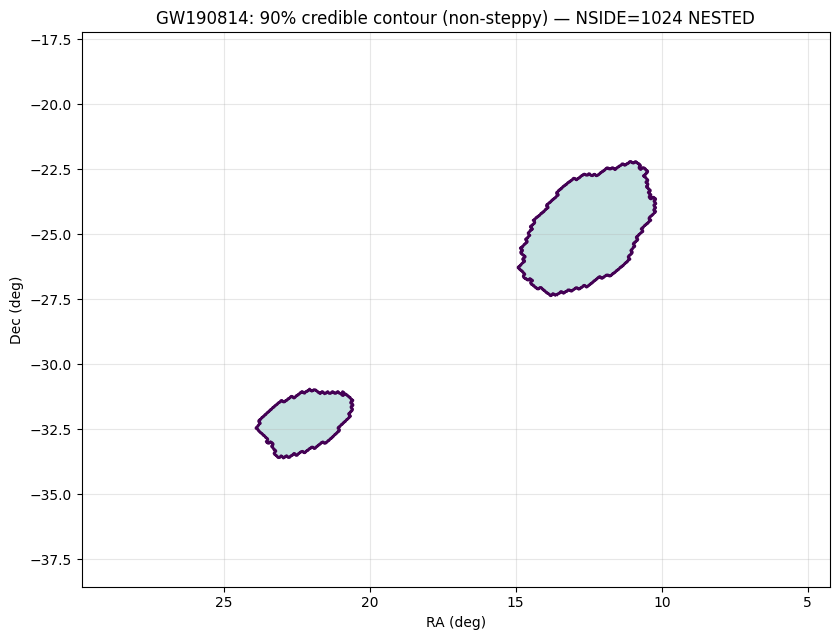

In [6]:
# ---------- Config ----------
SKYMAP_URL = "https://dcc.ligo.org/LIGO-P2000230/public/GW190814_skymap.fits.gz"
CREDIBLE = 0.90

# Zoomed plot grid resolution (higher = smoother contour, slower)
NGRID_RA = 1400
NGRID_DEC = 700

# Padding around the credible region (deg)
PAD_RA = 6.0
PAD_DEC = 5.0

FILL_REGION = True  # True = filled region + contour; False = contour only

# ---------- Imports (NO pip installs here) ----------
import os
import urllib.request
import numpy as np
import matplotlib.pyplot as plt

from astropy.table import Table
from astropy.io import fits
import astropy.units as u
from astropy_healpix import HEALPix


# ---------- Download ----------
fname = "GW190814_skymap.fits.gz"
if not os.path.exists(fname):
    urllib.request.urlretrieve(SKYMAP_URL, fname)

print("Skymap exists:", os.path.exists(fname))


# ---------- Read FITS header + table ----------
hdr = fits.getheader(fname, 1)          # ext 1 is usually the sky map table
t = Table.read(fname, hdu=1)
print("Columns:", t.colnames)

ordering = (hdr.get("ORDERING", "NESTED") or "NESTED").strip().upper()
if ordering not in ("NESTED", "RING"):
    print("Warning: unknown ORDERING:", ordering, "-> assuming NESTED")
    ordering = "NESTED"
order_for_healpix = "nested" if ordering == "NESTED" else "ring"

if "PROB" not in t.colnames:
    raise KeyError("Expected a raster sky map with a PROB column (probability per pixel).")

nside = hdr.get("NSIDE", None)
if nside is None:
    # Infer NSIDE from number of pixels if header is missing it
    npix = len(t["PROB"])
    nside_guess = int(round(np.sqrt(npix / 12.0)))
    if 12 * nside_guess * nside_guess != npix:
        raise ValueError("Couldn't infer NSIDE from PROB length; header also missing NSIDE.")
    nside = nside_guess

p = np.asarray(t["PROB"], dtype=float)
tot = p.sum()
if not np.isfinite(tot) or tot <= 0:
    raise RuntimeError("PROB column sums to non-finite or zero.")
p = p / tot  # normalize defensively

hp = HEALPix(nside=nside, order=order_for_healpix, frame="icrs")

print(f"Detected raster sky map: NSIDE={nside}, ORDERING={ordering}")
print("Total prob:", p.sum())


# ---------- Credible-level field (non-steppy contours) ----------
# For each pixel, credible_level[pix] = cumulative probability enclosed
# by all pixels with probability >= that pixel.
order = np.argsort(p)[::-1]
cum = np.cumsum(p[order])
credible_level = np.empty_like(p)
credible_level[order] = cum

# We'll still use the <=0.9 region just to compute a good zoom window.
mask90 = credible_level <= CREDIBLE
mask_pix = np.where(mask90)[0]

print(f"Pixels in {int(CREDIBLE*100)}% region:", mask_pix.size, "mass:", p[mask90].sum())


# ---------- Zoom window (wrap-safe RA) ----------
lon_c, lat_c = hp.healpix_to_lonlat(mask_pix)
ra_c = lon_c.to_value(u.deg)   # 0..360
dec_c = lat_c.to_value(u.deg)

def minimal_ra_window(ra_deg, pad_deg):
    """Smallest RA arc covering points (wrap-safe), returned as ra_min, ra_max in 0..360."""
    ra = np.mod(ra_deg, 360.0)
    ra_sorted = np.sort(ra)
    gaps = np.diff(np.r_[ra_sorted, ra_sorted[0] + 360.0])
    j = np.argmax(gaps)
    start = ra_sorted[(j + 1) % len(ra_sorted)]
    end = ra_sorted[j]
    ra_min = (start - pad_deg) % 360.0
    ra_max = (end + pad_deg) % 360.0
    return ra_min, ra_max

def ra_linspace_wrap(ra_min, ra_max, n):
    """Linspace over an RA window that may cross 360."""
    ra_min = ra_min % 360.0
    ra_max = ra_max % 360.0
    if ra_min <= ra_max:
        return np.linspace(ra_min, ra_max, n)
    else:
        a = np.linspace(ra_min, 360.0, n//2, endpoint=False)
        b = np.linspace(0.0, ra_max, n - len(a))
        return np.r_[a, b]

ra_min, ra_max = minimal_ra_window(ra_c, pad_deg=PAD_RA)
dec_min = dec_c.min() - PAD_DEC
dec_max = dec_c.max() + PAD_DEC


# ---------- Build a dense RA/Dec grid over the zoom window ----------
ra_vals = ra_linspace_wrap(ra_min, ra_max, NGRID_RA) * u.deg
dec_vals = np.linspace(dec_min, dec_max, NGRID_DEC) * u.deg
RA, DEC = np.meshgrid(ra_vals, dec_vals)

grid_pix = hp.lonlat_to_healpix(RA, DEC)

# IMPORTANT: contour the credible-level scalar field, not the binary mask
Z = credible_level[grid_pix]


# ---------- Plot (zoomed RA/Dec) ----------
plt.figure(figsize=(8.5, 6.5))
ax = plt.gca()

# Fill the 0..0.9 region and draw the 0.9 contour
if FILL_REGION:
    ax.contourf(RA.to_value(u.deg), DEC.to_value(u.deg), Z,
                levels=[0.0, CREDIBLE], alpha=0.25)

ax.contour(RA.to_value(u.deg), DEC.to_value(u.deg), Z,
           levels=[CREDIBLE], linewidths=2)

# Astronomy convention: RA increases to the left.
# If window wraps across 360, shift RA>180 down by 360 for a continuous axis.
ra_plot = RA.to_value(u.deg)
wrap = ra_min > ra_max

if wrap:
    ra_plot = np.where(ra_plot > 180.0, ra_plot - 360.0, ra_plot)

    # Replot using shifted RA coordinates
    plt.clf()
    plt.figure(figsize=(8.5, 6.5))
    ax = plt.gca()

    if FILL_REGION:
        ax.contourf(ra_plot, DEC.to_value(u.deg), Z,
                    levels=[0.0, CREDIBLE], alpha=0.25)
    ax.contour(ra_plot, DEC.to_value(u.deg), Z,
               levels=[CREDIBLE], linewidths=2)

    ra_min_s = ra_min - 360.0 if ra_min > 180.0 else ra_min
    ra_max_s = ra_max - 360.0 if ra_max > 180.0 else ra_max
    ax.set_xlim(ra_max_s, ra_min_s)  # inverted
else:
    ax.set_xlim(ra_max, ra_min)      # inverted

ax.set_ylim(dec_min, dec_max)
ax.set_xlabel("RA (deg)")
ax.set_ylabel("Dec (deg)")
ax.set_title(f"GW190814: {int(CREDIBLE*100)}% credible contour (non-steppy) — NSIDE={nside} {ordering}")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
!pip install healpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 26.5 MB/s eta 0:00:00


NSIDE=1024 ORDERING=NESTED   sum(p)=1.000000


/tmp/ipykernel_472/976181294.py:60: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  p_ring_s = hp.smoothing(p_ring, fwhm=fwhm_rad, verbose=False)


90% pixels: 5754  mass=0.899996


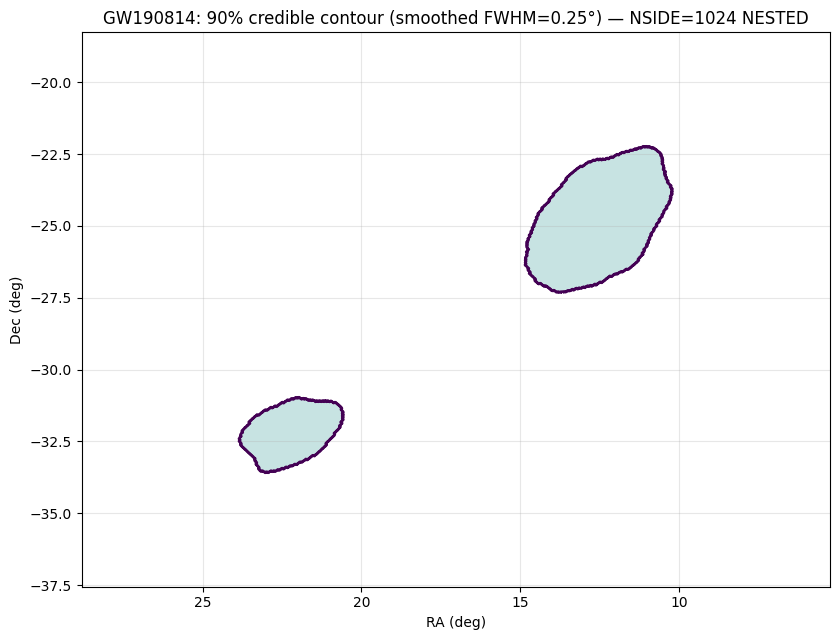

In [8]:
# ---------- Config ----------
SKYMAP_URL = "https://dcc.ligo.org/LIGO-P2000230/public/GW190814_skymap.fits.gz"
CREDIBLE = 0.90

# Smoothing kernel (degrees). 0 = no smoothing.
SMOOTH_FWHM_DEG = 0.25   # try 0.2–0.4

# Zoom plot grid resolution
NGRID_RA = 1800
NGRID_DEC = 900
PAD_RA = 5.0
PAD_DEC = 4.0
FILL_REGION = True

# ---------- Imports ----------
import os, urllib.request
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
from astropy.io import fits
import astropy.units as u
from astropy_healpix import HEALPix

import healpy as hp  # <-- for spherical smoothing + (optional) reordering

# ---------- Download ----------
fname = "GW190814_skymap.fits.gz"
if not os.path.exists(fname):
    urllib.request.urlretrieve(SKYMAP_URL, fname)

# ---------- Read header + table (raster case) ----------
hdr = fits.getheader(fname, 1)
t = Table.read(fname, hdu=1)

ordering = (hdr.get("ORDERING", "NESTED") or "NESTED").strip().upper()
if ordering not in ("NESTED", "RING"):
    ordering = "NESTED"

nside = hdr.get("NSIDE", None)
if nside is None:
    npix = len(t["PROB"])
    nside_guess = int(round(np.sqrt(npix / 12.0)))
    if 12 * nside_guess * nside_guess != npix:
        raise ValueError("Couldn't infer NSIDE.")
    nside = nside_guess

p = np.asarray(t["PROB"], dtype=float)
p = p / p.sum()

print(f"NSIDE={nside} ORDERING={ordering}   sum(p)={p.sum():.6f}")

# ---------- Smooth on the sphere (healpy works in RING by default) ----------
if ordering == "NESTED":
    p_ring = hp.reorder(p, n2r=True)
else:
    p_ring = p.copy()

if SMOOTH_FWHM_DEG and SMOOTH_FWHM_DEG > 0:
    fwhm_rad = np.deg2rad(SMOOTH_FWHM_DEG)
    p_ring_s = hp.smoothing(p_ring, fwhm=fwhm_rad, verbose=False)
    # enforce non-negative + renormalize (smoothing can make tiny negatives numerically)
    p_ring_s = np.clip(p_ring_s, 0, None)
    p_ring_s = p_ring_s / p_ring_s.sum()
else:
    p_ring_s = p_ring

# convert back to the map ordering we’ll use for astropy-healpix plotting
if ordering == "NESTED":
    p_s = hp.reorder(p_ring_s, r2n=True)
else:
    p_s = p_ring_s

# ---------- Build credible-level field from the (smoothed) map ----------
order_idx = np.argsort(p_s)[::-1]
cum = np.cumsum(p_s[order_idx])

credible = np.empty_like(p_s)
credible[order_idx] = cum

mask90 = credible <= CREDIBLE
mask_pix = np.where(mask90)[0]
print(f"90% pixels: {mask_pix.size}  mass={p_s[mask90].sum():.6f}")

# ---------- Setup HEALPix object for coordinate transforms ----------
hp_ast = HEALPix(nside=nside, order=("nested" if ordering == "NESTED" else "ring"), frame="icrs")

# ---------- Zoom window from mask pixels ----------
lon_c, lat_c = hp_ast.healpix_to_lonlat(mask_pix)
ra_c = lon_c.to_value(u.deg)   # 0..360
dec_c = lat_c.to_value(u.deg)

def minimal_ra_window(ra_deg, pad_deg):
    ra = np.mod(ra_deg, 360.0)
    ra_sorted = np.sort(ra)
    gaps = np.diff(np.r_[ra_sorted, ra_sorted[0] + 360.0])
    j = np.argmax(gaps)
    start = ra_sorted[(j + 1) % len(ra_sorted)]
    end = ra_sorted[j]
    return (start - pad_deg) % 360.0, (end + pad_deg) % 360.0

def ra_linspace_wrap(ra_min, ra_max, n):
    ra_min %= 360.0; ra_max %= 360.0
    if ra_min <= ra_max:
        return np.linspace(ra_min, ra_max, n)
    a = np.linspace(ra_min, 360.0, n//2, endpoint=False)
    b = np.linspace(0.0, ra_max, n - len(a))
    return np.r_[a, b]

ra_min, ra_max = minimal_ra_window(ra_c, PAD_RA)
dec_min = dec_c.min() - PAD_DEC
dec_max = dec_c.max() + PAD_DEC

# ---------- Grid + contour of the credible scalar field ----------
ra_vals = ra_linspace_wrap(ra_min, ra_max, NGRID_RA) * u.deg
dec_vals = np.linspace(dec_min, dec_max, NGRID_DEC) * u.deg
RA, DEC = np.meshgrid(ra_vals, dec_vals)

grid_pix = hp_ast.lonlat_to_healpix(RA, DEC)
Z = credible[grid_pix]

# ---------- Plot ----------
plt.figure(figsize=(8.5, 6.5))
ax = plt.gca()

if FILL_REGION:
    ax.contourf(RA.to_value(u.deg), DEC.to_value(u.deg), Z,
                levels=[0.0, CREDIBLE], alpha=0.25)

ax.contour(RA.to_value(u.deg), DEC.to_value(u.deg), Z,
           levels=[CREDIBLE], linewidths=2)

# RA increases to the left; handle wrap by shifting RA>180 down by 360
ra_plot = RA.to_value(u.deg)
wrap = ra_min > ra_max
if wrap:
    ra_plot = np.where(ra_plot > 180.0, ra_plot - 360.0, ra_plot)
    plt.clf()
    plt.figure(figsize=(8.5, 6.5))
    ax = plt.gca()
    if FILL_REGION:
        ax.contourf(ra_plot, DEC.to_value(u.deg), Z, levels=[0.0, CREDIBLE], alpha=0.25)
    ax.contour(ra_plot, DEC.to_value(u.deg), Z, levels=[CREDIBLE], linewidths=2)
    ra_min_s = ra_min - 360.0 if ra_min > 180.0 else ra_min
    ra_max_s = ra_max - 360.0 if ra_max > 180.0 else ra_max
    ax.set_xlim(ra_max_s, ra_min_s)
else:
    ax.set_xlim(ra_max, ra_min)

ax.set_ylim(dec_min, dec_max)
ax.set_xlabel("RA (deg)")
ax.set_ylabel("Dec (deg)")
ax.set_title(f"GW190814: 90% credible contour (smoothed FWHM={SMOOTH_FWHM_DEG}°) — NSIDE={nside} {ordering}")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

NSIDE=1024 ORDERING=NESTED   sum(p)=1.000000


/tmp/ipykernel_472/933968634.py:61: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  p_ring_s = hp.smoothing(p_ring, fwhm=fwhm_rad, verbose=False)


90% pixels total: 5754  mass=0.899996
Islands found: 2 masses: [0.82471229 0.07528329]
Main island: pixels=4294, mass=0.824712


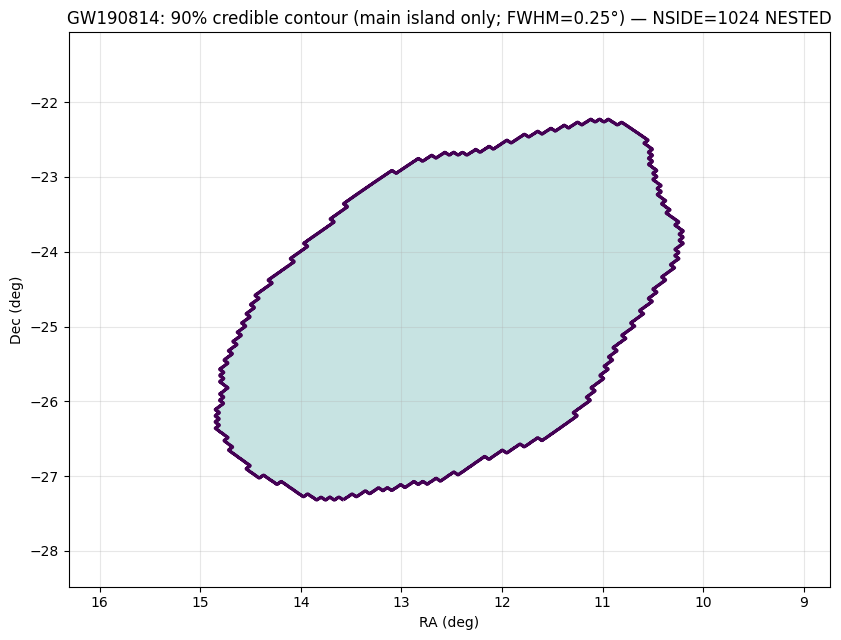

In [9]:
# ---------- Config ----------
SKYMAP_URL = "https://dcc.ligo.org/LIGO-P2000230/public/GW190814_skymap.fits.gz"
CREDIBLE = 0.90

# Smoothing kernel (degrees). 0 = no smoothing.
SMOOTH_FWHM_DEG = 0.25   # try 0.2–0.4

# Zoom plot grid resolution
NGRID_RA = 3500
NGRID_DEC = 1750
PAD_RA = 1.5
PAD_DEC = 1.2
FILL_REGION = True

# Connectivity for "islands": 8-neighbour HEALPix adjacency (standard)
# (HEALPix neighbours returns up to 8 neighbours; -1 means none)
# ---------- Imports ----------
import os, urllib.request
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
from astropy.io import fits
import astropy.units as u
from astropy_healpix import HEALPix
import healpy as hp  # spherical smoothing + reorder

# ---------- Download ----------
fname = "GW190814_skymap.fits.gz"
if not os.path.exists(fname):
    urllib.request.urlretrieve(SKYMAP_URL, fname)

# ---------- Read header + table ----------
hdr = fits.getheader(fname, 1)
t = Table.read(fname, hdu=1)

ordering = (hdr.get("ORDERING", "NESTED") or "NESTED").strip().upper()
if ordering not in ("NESTED", "RING"):
    ordering = "NESTED"

nside = hdr.get("NSIDE", None)
if nside is None:
    npix = len(t["PROB"])
    nside_guess = int(round(np.sqrt(npix / 12.0)))
    if 12 * nside_guess * nside_guess != npix:
        raise ValueError("Couldn't infer NSIDE.")
    nside = nside_guess

p = np.asarray(t["PROB"], dtype=float)
p = p / p.sum()

print(f"NSIDE={nside} ORDERING={ordering}   sum(p)={p.sum():.6f}")

# ---------- Smooth on the sphere (healpy smoothing works in RING) ----------
if ordering == "NESTED":
    p_ring = hp.reorder(p, n2r=True)
else:
    p_ring = p.copy()

if SMOOTH_FWHM_DEG and SMOOTH_FWHM_DEG > 0:
    fwhm_rad = np.deg2rad(SMOOTH_FWHM_DEG)
    p_ring_s = hp.smoothing(p_ring, fwhm=fwhm_rad, verbose=False)
    p_ring_s = np.clip(p_ring_s, 0, None)
    p_ring_s = p_ring_s / p_ring_s.sum()
else:
    p_ring_s = p_ring

# Back to original ordering for astropy-healpix
if ordering == "NESTED":
    p_s = hp.reorder(p_ring_s, r2n=True)
else:
    p_s = p_ring_s

# ---------- Credible-level field from smoothed map ----------
order_idx = np.argsort(p_s)[::-1]
cum = np.cumsum(p_s[order_idx])
credible = np.empty_like(p_s)
credible[order_idx] = cum

mask90 = credible <= CREDIBLE
mask_pix = np.where(mask90)[0]
print(f"90% pixels total: {mask_pix.size}  mass={p_s[mask90].sum():.6f}")

# ---------- HEALPix object for neighbours + coordinate transforms ----------
hp_ast = HEALPix(nside=nside, order=("nested" if ordering == "NESTED" else "ring"), frame="icrs")

# ---------- Find connected components (islands) within the 90% mask ----------
mask_set = set(mask_pix.tolist())
visited = set()

components = []          # list of lists of pixel indices
components_mass = []     # probability mass per component (using p_s)

for start in mask_pix:
    if start in visited:
        continue

    # BFS/DFS
    stack = [int(start)]
    visited.add(int(start))
    comp = []
    mass = 0.0

    while stack:
        pix = stack.pop()
        comp.append(pix)
        mass += float(p_s[pix])

        neigh = hp_ast.neighbours(pix)  # up to 8 neighbours; may include -1
        for nb in neigh:
            nb_int = int(nb)
            if nb_int >= 0 and nb_int in mask_set and nb_int not in visited:
                visited.add(nb_int)
                stack.append(nb_int)

    components.append(comp)
    components_mass.append(mass)

components_mass = np.array(components_mass, dtype=float)
print("Islands found:", len(components), "masses:", components_mass)

main_i = int(np.argmax(components_mass))
main_pix = np.array(components[main_i], dtype=int)
print(f"Main island: pixels={main_pix.size}, mass={components_mass[main_i]:.6f}")

# ---------- Zoom window from MAIN island only ----------
lon_c, lat_c = hp_ast.healpix_to_lonlat(main_pix)
ra_c = lon_c.to_value(u.deg)   # 0..360
dec_c = lat_c.to_value(u.deg)

def minimal_ra_window(ra_deg, pad_deg):
    ra = np.mod(ra_deg, 360.0)
    ra_sorted = np.sort(ra)
    gaps = np.diff(np.r_[ra_sorted, ra_sorted[0] + 360.0])
    j = np.argmax(gaps)
    start = ra_sorted[(j + 1) % len(ra_sorted)]
    end = ra_sorted[j]
    return (start - pad_deg) % 360.0, (end + pad_deg) % 360.0

def ra_linspace_wrap(ra_min, ra_max, n):
    ra_min %= 360.0; ra_max %= 360.0
    if ra_min <= ra_max:
        return np.linspace(ra_min, ra_max, n)
    a = np.linspace(ra_min, 360.0, n//2, endpoint=False)
    b = np.linspace(0.0, ra_max, n - len(a))
    return np.r_[a, b]

ra_min, ra_max = minimal_ra_window(ra_c, PAD_RA)
dec_min = dec_c.min() - PAD_DEC
dec_max = dec_c.max() + PAD_DEC

# ---------- Build grid + contour credible field at 0.9 ----------
ra_vals = ra_linspace_wrap(ra_min, ra_max, NGRID_RA) * u.deg
dec_vals = np.linspace(dec_min, dec_max, NGRID_DEC) * u.deg
RA, DEC = np.meshgrid(ra_vals, dec_vals)

grid_pix = hp_ast.lonlat_to_healpix(RA, DEC)
Z = credible[grid_pix]  # scalar credible field (smoothed via p_s)

# ---------- Plot ----------
plt.figure(figsize=(8.5, 6.5))
ax = plt.gca()

if FILL_REGION:
    ax.contourf(RA.to_value(u.deg), DEC.to_value(u.deg), Z, levels=[0.0, CREDIBLE], alpha=0.25)

ax.contour(RA.to_value(u.deg), DEC.to_value(u.deg), Z, levels=[CREDIBLE], linewidths=2.2, antialiased=True)

# RA increases to the left; handle wrap by shifting RA>180 down by 360
ra_plot = RA.to_value(u.deg)
wrap = ra_min > ra_max
if wrap:
    ra_plot = np.where(ra_plot > 180.0, ra_plot - 360.0, ra_plot)
    plt.clf()
    plt.figure(figsize=(8.5, 6.5))
    ax = plt.gca()
    if FILL_REGION:
        ax.contourf(ra_plot, DEC.to_value(u.deg), Z, levels=[0.0, CREDIBLE], alpha=0.25)
    ax.contour(ra_plot, DEC.to_value(u.deg), Z, levels=[CREDIBLE], linewidths=2)

    ra_min_s = ra_min - 360.0 if ra_min > 180.0 else ra_min
    ra_max_s = ra_max - 360.0 if ra_max > 180.0 else ra_max
    ax.set_xlim(ra_max_s, ra_min_s)
else:
    ax.set_xlim(ra_max, ra_min)

ax.set_ylim(dec_min, dec_max)
ax.set_xlabel("RA (deg)")
ax.set_ylabel("Dec (deg)")
ax.set_title(
    f"GW190814: {int(CREDIBLE*100)}% credible contour (main island only; FWHM={SMOOTH_FWHM_DEG}°) — NSIDE={nside} {ordering}"
)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

NSIDE=1024 ORDERING=NESTED   sum(p)=1.000000


/tmp/ipykernel_472/1464504262.py:66: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  p_ring_s = hp.smoothing(p_ring, fwhm=fwhm_rad, verbose=False)


90% pixels total: 5754  mass=0.899996
Main island: pixels=4294, mass=0.824712
Galaxies loaded: 273
Inside main-island 90% region: 269 / 273


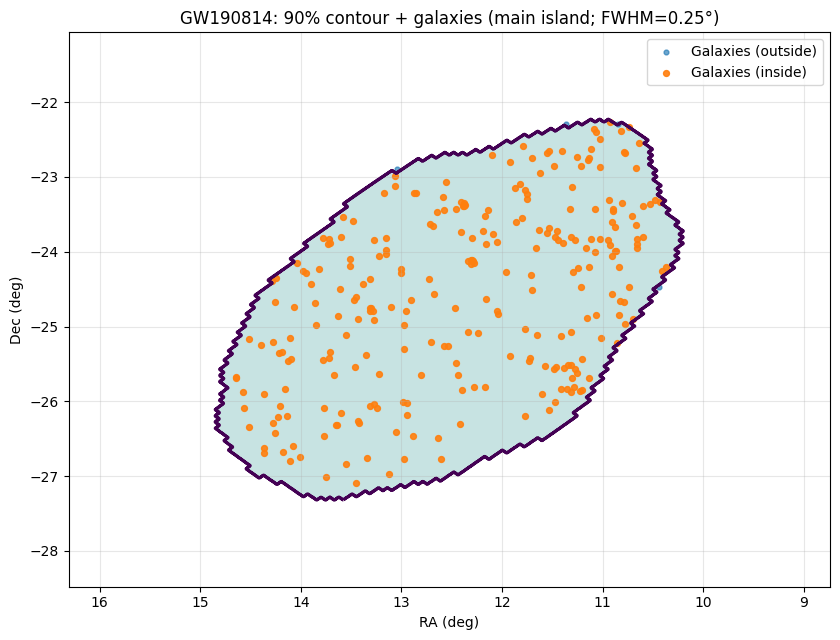

In [10]:
# ---------- Config ----------
SKYMAP_URL = "https://dcc.ligo.org/LIGO-P2000230/public/GW190814_skymap.fits.gz"
CREDIBLE = 0.90

SMOOTH_FWHM_DEG = 0.25   # smoothing for nicer contour
NGRID_RA = 3500
NGRID_DEC = 1750
PAD_RA = 1.5
PAD_DEC = 1.2
FILL_REGION = True

# Your galaxy CSV path:
GALAXY_CSV = "galaxy.csv"   # <-- change me

# Column names in the CSV:
RA_COL = "ra"     # or "RA"
DEC_COL = "dec"   # or "Dec"

# ---------- Imports ----------
import os, urllib.request
import numpy as np
import matplotlib.pyplot as plt

from astropy.table import Table
from astropy.io import fits
import astropy.units as u
from astropy_healpix import HEALPix

import healpy as hp
import pandas as pd

# ---------- Download skymap ----------
fname = "GW190814_skymap.fits.gz"
if not os.path.exists(fname):
    urllib.request.urlretrieve(SKYMAP_URL, fname)

# ---------- Read skymap (raster PROB) ----------
hdr = fits.getheader(fname, 1)
t = Table.read(fname, hdu=1)

ordering = (hdr.get("ORDERING", "NESTED") or "NESTED").strip().upper()
if ordering not in ("NESTED", "RING"):
    ordering = "NESTED"

nside = hdr.get("NSIDE", None)
if nside is None:
    npix = len(t["PROB"])
    nside_guess = int(round(np.sqrt(npix / 12.0)))
    if 12 * nside_guess * nside_guess != npix:
        raise ValueError("Couldn't infer NSIDE.")
    nside = nside_guess

p = np.asarray(t["PROB"], dtype=float)
p = p / p.sum()

print(f"NSIDE={nside} ORDERING={ordering}   sum(p)={p.sum():.6f}")

# ---------- Smooth on sphere (healpy uses RING) ----------
if ordering == "NESTED":
    p_ring = hp.reorder(p, n2r=True)
else:
    p_ring = p.copy()

if SMOOTH_FWHM_DEG and SMOOTH_FWHM_DEG > 0:
    fwhm_rad = np.deg2rad(SMOOTH_FWHM_DEG)
    p_ring_s = hp.smoothing(p_ring, fwhm=fwhm_rad, verbose=False)
    p_ring_s = np.clip(p_ring_s, 0, None)
    p_ring_s = p_ring_s / p_ring_s.sum()
else:
    p_ring_s = p_ring

if ordering == "NESTED":
    p_s = hp.reorder(p_ring_s, r2n=True)
else:
    p_s = p_ring_s

# ---------- Credible-level field ----------
order_idx = np.argsort(p_s)[::-1]
cum = np.cumsum(p_s[order_idx])
credible = np.empty_like(p_s)
credible[order_idx] = cum

mask90 = credible <= CREDIBLE
mask_pix = np.where(mask90)[0]
print(f"90% pixels total: {mask_pix.size}  mass={p_s[mask90].sum():.6f}")

# ---------- HEALPix helper ----------
hp_ast = HEALPix(nside=nside, order=("nested" if ordering == "NESTED" else "ring"), frame="icrs")

# ---------- Find connected components (main island only) ----------
mask_set = set(mask_pix.tolist())
visited = set()
components = []
components_mass = []

for start in mask_pix:
    s = int(start)
    if s in visited:
        continue
    stack = [s]
    visited.add(s)
    comp = []
    mass = 0.0

    while stack:
        pix = stack.pop()
        comp.append(pix)
        mass += float(p_s[pix])

        neigh = hp_ast.neighbours(pix)
        for nb in neigh:
            nb = int(nb)
            if nb >= 0 and nb in mask_set and nb not in visited:
                visited.add(nb)
                stack.append(nb)

    components.append(comp)
    components_mass.append(mass)

components_mass = np.array(components_mass, dtype=float)
main_i = int(np.argmax(components_mass))
main_pix = np.array(components[main_i], dtype=int)
print(f"Main island: pixels={main_pix.size}, mass={components_mass[main_i]:.6f}")

# We'll use this mask for "inside/outside" galaxy coloring:
mask_main = np.zeros_like(mask90, dtype=bool)
mask_main[main_pix] = True

# ---------- Zoom window from main island ----------
lon_c, lat_c = hp_ast.healpix_to_lonlat(main_pix)
ra_c = lon_c.to_value(u.deg)   # 0..360
dec_c = lat_c.to_value(u.deg)

def minimal_ra_window(ra_deg, pad_deg):
    ra = np.mod(ra_deg, 360.0)
    ra_sorted = np.sort(ra)
    gaps = np.diff(np.r_[ra_sorted, ra_sorted[0] + 360.0])
    j = np.argmax(gaps)
    start = ra_sorted[(j + 1) % len(ra_sorted)]
    end = ra_sorted[j]
    return (start - pad_deg) % 360.0, (end + pad_deg) % 360.0

def ra_linspace_wrap(ra_min, ra_max, n):
    ra_min %= 360.0; ra_max %= 360.0
    if ra_min <= ra_max:
        return np.linspace(ra_min, ra_max, n)
    a = np.linspace(ra_min, 360.0, n//2, endpoint=False)
    b = np.linspace(0.0, ra_max, n - len(a))
    return np.r_[a, b]

ra_min, ra_max = minimal_ra_window(ra_c, PAD_RA)
dec_min = dec_c.min() - PAD_DEC
dec_max = dec_c.max() + PAD_DEC

# ---------- Build contour grid ----------
ra_vals = ra_linspace_wrap(ra_min, ra_max, NGRID_RA) * u.deg
dec_vals = np.linspace(dec_min, dec_max, NGRID_DEC) * u.deg
RA, DEC = np.meshgrid(ra_vals, dec_vals)

grid_pix = hp_ast.lonlat_to_healpix(RA, DEC)
Z = credible[grid_pix]

# ---------- Load galaxies ----------
df = pd.read_csv(GALAXY_CSV)

# tolerant column lookup
cols_lower = {c.lower(): c for c in df.columns}
ra_key = cols_lower.get(RA_COL.lower(), RA_COL)
dec_key = cols_lower.get(DEC_COL.lower(), DEC_COL)

if ra_key not in df.columns or dec_key not in df.columns:
    raise KeyError(f"Couldn't find RA/Dec columns. Have {list(df.columns)}; tried {RA_COL}, {DEC_COL}.")

gal_ra = df[ra_key].astype(float).to_numpy()
gal_dec = df[dec_key].astype(float).to_numpy()

# Wrap RA into 0..360 for HEALPix
gal_ra_wrapped = np.mod(gal_ra, 360.0) * u.deg
gal_dec_u = gal_dec * u.deg

gal_pix = hp_ast.lonlat_to_healpix(gal_ra_wrapped, gal_dec_u)
gal_in = mask_main[gal_pix]

print(f"Galaxies loaded: {len(gal_ra)}")
print(f"Inside main-island {int(CREDIBLE*100)}% region: {gal_in.sum()} / {len(gal_in)}")

# ---------- Plot ----------
plt.figure(figsize=(8.5, 6.5))
ax = plt.gca()

# Contour fill + line
if FILL_REGION:
    ax.contourf(RA.to_value(u.deg), DEC.to_value(u.deg), Z, levels=[0.0, CREDIBLE], alpha=0.25)
ax.contour(RA.to_value(u.deg), DEC.to_value(u.deg), Z, levels=[CREDIBLE], linewidths=2.2, antialiased=True)

# Plot galaxies: inside vs outside
# (No fixed colors requested; matplotlib will choose defaults)
ax.scatter(gal_ra[~gal_in], gal_dec[~gal_in], s=12, alpha=0.65, marker="o", label="Galaxies (outside)")
ax.scatter(gal_ra[gal_in],  gal_dec[gal_in],  s=18, alpha=0.9,  marker="o", label="Galaxies (inside)")

# RA axis handling (invert; wrap-safe)
wrap = ra_min > ra_max
if wrap:
    # shift display RA for continuity
    def shift_ra(x):
        x = np.mod(x, 360.0)
        return np.where(x > 180.0, x - 360.0, x)

    ra_plot = shift_ra(RA.to_value(u.deg))
    gal_ra_plot = shift_ra(gal_ra)

    plt.clf()
    plt.figure(figsize=(8.5, 6.5))
    ax = plt.gca()
    if FILL_REGION:
        ax.contourf(ra_plot, DEC.to_value(u.deg), Z, levels=[0.0, CREDIBLE], alpha=0.25)
    ax.contour(ra_plot, DEC.to_value(u.deg), Z, levels=[CREDIBLE], linewidths=2.2, antialiased=True)

    ax.scatter(gal_ra_plot[~gal_in], gal_dec[~gal_in], s=12, alpha=0.65, marker="o", label="Galaxies (outside)")
    ax.scatter(gal_ra_plot[gal_in],  gal_dec[gal_in],  s=18, alpha=0.9,  marker="o", label="Galaxies (inside)")

    ra_min_s = (ra_min - 360.0) if ra_min > 180.0 else ra_min
    ra_max_s = (ra_max - 360.0) if ra_max > 180.0 else ra_max
    ax.set_xlim(ra_max_s, ra_min_s)
else:
    ax.set_xlim(ra_max, ra_min)

ax.set_ylim(dec_min, dec_max)
ax.set_xlabel("RA (deg)")
ax.set_ylabel("Dec (deg)")
ax.set_title(f"GW190814: {int(CREDIBLE*100)}% contour + galaxies (main island; FWHM={SMOOTH_FWHM_DEG}°)")
ax.grid(True, alpha=0.3)
ax.legend(loc="best")
plt.tight_layout()
plt.show()

In [11]:
import numpy as np

# ----------------------------
# Config for WEAVE MOS
# ----------------------------
RADIUS_DEG = 1.0     # WEAVE MOS radius
NMAX = 10            # compute solutions for N=1..NMAX
USE_ONLY_GALAXIES_IN_ISLAND_AS_CANDIDATES = True  # recommended for speed + constraint

# ----------------------------
# Helpers: spherical geometry
# ----------------------------
def radec_to_unitvec(ra_deg, dec_deg):
    """Convert RA/Dec (deg) to Cartesian unit vectors."""
    ra = np.deg2rad(ra_deg)
    dec = np.deg2rad(dec_deg)
    cosd = np.cos(dec)
    return np.column_stack([cosd*np.cos(ra), cosd*np.sin(ra), np.sin(dec)])

def angular_sep_deg_vec(v1, v2):
    """Angular separation (deg) between vectors v1 (N,3) and v2 (M,3) via dot products."""
    # returns (N,M)
    dots = np.clip(v1 @ v2.T, -1.0, 1.0)
    return np.rad2deg(np.arccos(dots))

def is_center_in_main_island(ra_deg, dec_deg, hp_ast, mask_main):
    """Check if a candidate center falls in the main island mask."""
    import astropy.units as u
    ra_u = (np.mod(ra_deg, 360.0) * u.deg)
    dec_u = (dec_deg * u.deg)
    pix = hp_ast.lonlat_to_healpix(ra_u, dec_u)
    return bool(mask_main[int(pix)])

# ----------------------------
# Build galaxy point set to cover
# ----------------------------
# gal_ra, gal_dec are your full catalog arrays (deg)
gal_ra = np.asarray(gal_ra, dtype=float)
gal_dec = np.asarray(gal_dec, dtype=float)

# Determine which galaxies are in the main island (you already computed gal_pix + mask_main earlier)
# If you don't have gal_pix/gal_in already, recompute here:
import astropy.units as u
gal_pix = hp_ast.lonlat_to_healpix((np.mod(gal_ra, 360.0) * u.deg), (gal_dec * u.deg))
gal_in_main = mask_main[np.asarray(gal_pix, dtype=int)]

# For the proposal exercise you probably want to cover only galaxies in/near the localisation.
# If you want "all galaxies plotted" (including outside), set TARGET = all.
TARGET = np.where(gal_in_main)[0]  # indices of galaxies to cover
# TARGET = np.arange(len(gal_ra))  # uncomment if you instead want to cover the entire input catalog

target_ra = gal_ra[TARGET]
target_dec = gal_dec[TARGET]
target_vec = radec_to_unitvec(target_ra, target_dec)

print(f"Target galaxies for coverage: {len(TARGET)}")

# ----------------------------
# Candidate pointing centers
# ----------------------------
# A very practical choice is: candidate centers = the galaxy positions (in main island),
# because the optimum for max-count under a fixed radius almost always occurs with a boundary
# "supported" by points. With 300 galaxies this is plenty.

if USE_ONLY_GALAXIES_IN_ISLAND_AS_CANDIDATES:
    cand_idx = np.arange(len(TARGET))  # candidate centers = target galaxies
    cand_ra = target_ra.copy()
    cand_dec = target_dec.copy()
else:
    # Candidate centers = all galaxies (or you can add a grid later)
    cand_ra = gal_ra.copy()
    cand_dec = gal_dec.copy()

# Enforce "center must be in the island" explicitly
in_island = np.array([is_center_in_main_island(r, d, hp_ast, mask_main) for r, d in zip(cand_ra, cand_dec)])
cand_ra = cand_ra[in_island]
cand_dec = cand_dec[in_island]

if len(cand_ra) == 0:
    raise RuntimeError("No candidate centers remained after island constraint.")

cand_vec = radec_to_unitvec(cand_ra, cand_dec)

# Precompute which targets are within 1° of each candidate center
# cover_matrix[i] = boolean mask over targets covered by candidate i
sep = angular_sep_deg_vec(cand_vec, target_vec)           # (Ncand, Ntarget)
cover_matrix = (sep <= RADIUS_DEG)

# ----------------------------
# Greedy maximum coverage for N pointings
# ----------------------------
covered = np.zeros(len(TARGET), dtype=bool)
pointings = []

for n in range(1, NMAX + 1):
    # marginal gain for each candidate = number of uncovered galaxies it would newly cover
    gains = np.sum(cover_matrix & (~covered[None, :]), axis=1)
    best = int(np.argmax(gains))
    best_gain = int(gains[best])

    if best_gain == 0:
        print(f"Stopping early at N={n-1}: no further galaxies can be added with radius={RADIUS_DEG}°.")
        break

    # update covered set
    newly = cover_matrix[best] & (~covered)
    covered |= cover_matrix[best]

    # record
    cum = int(covered.sum())
    pct = 100.0 * cum / len(TARGET)

    pointings.append({
        "N": n,
        "ra_deg": float(cand_ra[best]),
        "dec_deg": float(cand_dec[best]),
        "newly_covered": int(newly.sum()),
        "cumulative_covered": cum,
        "cumulative_pct": pct
    })

# ----------------------------
# Report
# ----------------------------
if pointings:
    print("\nBest single pointing (N=1):")
    p1 = pointings[0]
    print(f"  center RA,Dec = ({p1['ra_deg']:.6f}°, {p1['dec_deg']:.6f}°)")
    print(f"  galaxies covered = {p1['cumulative_covered']} / {len(TARGET)}  ({p1['cumulative_pct']:.2f}%)")

print("\nGreedy coverage curve:")
for p in pointings:
    print(f"  N={p['N']:2d}  center=({p['ra_deg']:.4f}, {p['dec_deg']:.4f})  "
          f"+{p['newly_covered']:3d}  cum={p['cumulative_covered']:3d}  ({p['cumulative_pct']:.2f}%)")

Target galaxies for coverage: 269
Stopping early at N=9: no further galaxies can be added with radius=1.0°.

Best single pointing (N=1):
  center RA,Dec = (11.536177°, -23.678470°)
  galaxies covered = 81 / 269  (30.11%)

Greedy coverage curve:
  N= 1  center=(11.5362, -23.6785)  + 81  cum= 81  (30.11%)
  N= 2  center=(13.3102, -24.7975)  + 61  cum=142  (52.79%)
  N= 3  center=(11.6543, -25.1149)  + 45  cum=187  (69.52%)
  N= 4  center=(13.6385, -26.3185)  + 38  cum=225  (83.64%)
  N= 5  center=(11.2995, -23.1319)  + 18  cum=243  (90.33%)
  N= 6  center=(13.1577, -23.8209)  + 15  cum=258  (95.91%)
  N= 7  center=(11.7764, -26.2017)  +  4  cum=262  (97.40%)
  N= 8  center=(14.2047, -26.0660)  +  4  cum=266  (98.88%)
  N= 9  center=(10.4143, -24.2531)  +  3  cum=269  (100.00%)


In [12]:
from matplotlib.patches import Circle

# Plot circles for each pointing
for p in pointings:
    ra = p["ra_deg"]
    dec = p["dec_deg"]

    circle = Circle(
        (ra, dec),
        RADIUS_DEG,
        fill=False,
        linewidth=2,
        linestyle="--",
        alpha=0.9
    )

    ax.add_patch(circle)

    # label the pointing
    ax.text(
        ra,
        dec,
        f"P{p['N']}",
        ha="center",
        va="center",
        fontsize=10,
        weight="bold"
    )

Skymap: NSIDE=1024 ORDERING=NESTED  sum(PROB)=1.000000


/tmp/ipykernel_472/2756621071.py:81: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  p_ring_s = hp.smoothing(p_ring, fwhm=fwhm_rad, verbose=False)


90% region (all islands): pixels=5754 mass=0.899996
Main island: pixels=4294 mass=0.824712
Galaxies loaded: 273  inside main island 90%: 269

Pointing plan (greedy):
  P1: center=(11.5362, -23.6785) + 81  cum= 81/269 (30.11%)
  P2: center=(13.3102, -24.7975) + 61  cum=142/269 (52.79%)
  P3: center=(11.6543, -25.1149) + 45  cum=187/269 (69.52%)
  P4: center=(13.6385, -26.3185) + 38  cum=225/269 (83.64%)
  P5: center=(11.2995, -23.1319) + 18  cum=243/269 (90.33%)
  P6: center=(13.1577, -23.8209) + 15  cum=258/269 (95.91%)


/tmp/ipykernel_472/2756621071.py:306: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="best")


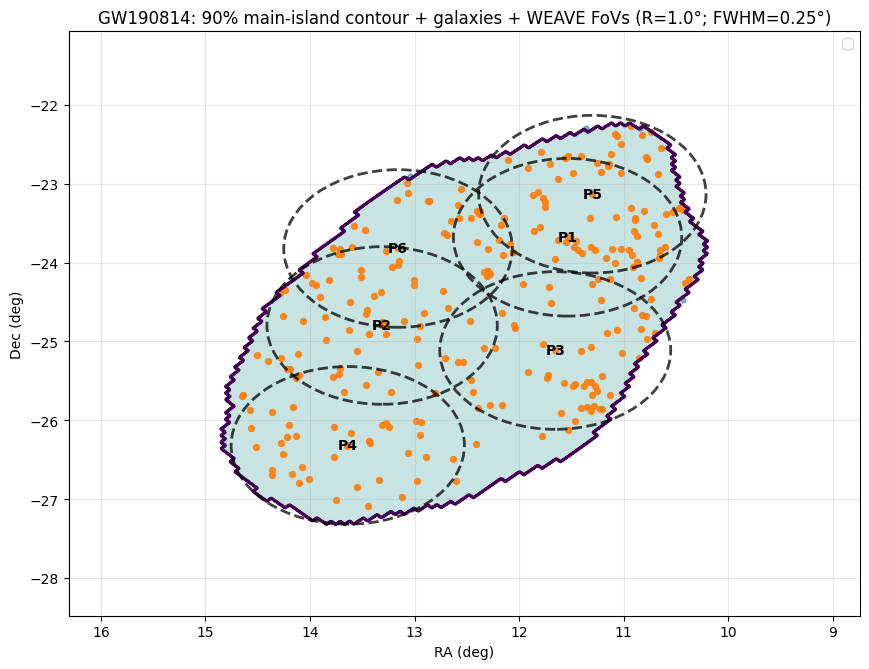

In [13]:
# ============================================================
# ONE CELL: GW190814 90% (main-island) contour + galaxies + WEAVE FoV circles
# - Reads GW190814 skymap (PROB raster)
# - Smooths posterior on the sphere (for prettier contours)
# - Finds the 90% credible MAIN island (largest connected component)
# - Loads galaxy CSV (RA/Dec)
# - Chooses best WEAVE MOS pointings (greedy) with radius=1 deg
# - Plots: 90% contour + galaxies + FoV circles + P1..PN labels
# ============================================================

# ---------- USER SETTINGS ----------
GALAXY_CSV = "galaxy.csv"   # <-- put your CSV filename here
RA_COL = "ra"                 # <-- column name in CSV for RA (deg)
DEC_COL = "dec"               # <-- column name in CSV for Dec (deg)

N_POINTINGS = 6               # <-- how many WEAVE pointings to plot (P1..PN)
WEAVE_RADIUS_DEG = 1.0        # WEAVE MOS radius (deg)

CREDIBLE = 0.90
SMOOTH_FWHM_DEG = 0.25        # try 0.2–0.35 for nicer-looking outlines
PAD_RA_DEG = 1.5              # zoom margin (deg)
PAD_DEC_DEG = 1.2             # zoom margin (deg)

# Plot grid (increase if you want smoother-looking contours; may slow down)
NGRID_RA = 2500
NGRID_DEC = 1200

# ---------- DO NOT EDIT BELOW UNLESS YOU WANT TO ----------
import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

from astropy.io import fits
from astropy.table import Table
import astropy.units as u
from astropy_healpix import HEALPix

import healpy as hp


# ---------- Download skymap ----------
SKYMAP_URL = "https://dcc.ligo.org/LIGO-P2000230/public/GW190814_skymap.fits.gz"
fname = "GW190814_skymap.fits.gz"
if not os.path.exists(fname):
    urllib.request.urlretrieve(SKYMAP_URL, fname)

# ---------- Read skymap (raster PROB) ----------
hdr = fits.getheader(fname, 1)
t = Table.read(fname, hdu=1)

if "PROB" not in t.colnames:
    raise KeyError(f"Expected a raster sky map with PROB column; got columns: {t.colnames}")

ordering = (hdr.get("ORDERING", "NESTED") or "NESTED").strip().upper()
if ordering not in ("NESTED", "RING"):
    ordering = "NESTED"

nside = hdr.get("NSIDE", None)
if nside is None:
    npix = len(t["PROB"])
    nside_guess = int(round(np.sqrt(npix / 12.0)))
    if 12 * nside_guess * nside_guess != npix:
        raise ValueError("Couldn't infer NSIDE from PROB length; header also missing NSIDE.")
    nside = nside_guess

p = np.asarray(t["PROB"], dtype=float)
p = p / p.sum()

print(f"Skymap: NSIDE={nside} ORDERING={ordering}  sum(PROB)={p.sum():.6f}")

# ---------- Smooth posterior on sphere (healpy smoothing expects RING) ----------
if ordering == "NESTED":
    p_ring = hp.reorder(p, n2r=True)
else:
    p_ring = p.copy()

if SMOOTH_FWHM_DEG and SMOOTH_FWHM_DEG > 0:
    fwhm_rad = np.deg2rad(SMOOTH_FWHM_DEG)
    p_ring_s = hp.smoothing(p_ring, fwhm=fwhm_rad, verbose=False)
    p_ring_s = np.clip(p_ring_s, 0, None)
    p_ring_s = p_ring_s / p_ring_s.sum()
else:
    p_ring_s = p_ring

if ordering == "NESTED":
    p_s = hp.reorder(p_ring_s, r2n=True)
else:
    p_s = p_ring_s

# ---------- Credible level per pixel ----------
order_idx = np.argsort(p_s)[::-1]
cum = np.cumsum(p_s[order_idx])
credible = np.empty_like(p_s)
credible[order_idx] = cum

mask90 = credible <= CREDIBLE
mask_pix = np.where(mask90)[0]
print(f"90% region (all islands): pixels={mask_pix.size} mass={p_s[mask90].sum():.6f}")

# ---------- HEALPix helper ----------
hp_ast = HEALPix(nside=nside, order=("nested" if ordering == "NESTED" else "ring"), frame="icrs")

# ---------- Find MAIN island within 90% region (connected components via neighbours) ----------
mask_set = set(mask_pix.tolist())
visited = set()
components = []
components_mass = []

for start in mask_pix:
    s = int(start)
    if s in visited:
        continue
    stack = [s]
    visited.add(s)
    comp = []
    mass = 0.0
    while stack:
        pix = stack.pop()
        comp.append(pix)
        mass += float(p_s[pix])
        neigh = hp_ast.neighbours(pix)  # up to 8 neighbours; -1 means none
        for nb in neigh:
            nb = int(nb)
            if nb >= 0 and nb in mask_set and nb not in visited:
                visited.add(nb)
                stack.append(nb)
    components.append(comp)
    components_mass.append(mass)

components_mass = np.array(components_mass, dtype=float)
main_i = int(np.argmax(components_mass))
main_pix = np.array(components[main_i], dtype=int)

mask_main = np.zeros_like(mask90, dtype=bool)
mask_main[main_pix] = True

print(f"Main island: pixels={main_pix.size} mass={components_mass[main_i]:.6f}")

# ---------- Load galaxies ----------
df = pd.read_csv(GALAXY_CSV)

# tolerant column lookup (case-insensitive)
cols_lower = {c.lower(): c for c in df.columns}
ra_key = cols_lower.get(RA_COL.lower(), RA_COL)
dec_key = cols_lower.get(DEC_COL.lower(), DEC_COL)

if ra_key not in df.columns or dec_key not in df.columns:
    raise KeyError(f"Couldn't find RA/Dec columns. CSV has {list(df.columns)}; tried {RA_COL}/{DEC_COL}.")

gal_ra = df[ra_key].astype(float).to_numpy()
gal_dec = df[dec_key].astype(float).to_numpy()

# Determine which galaxies are inside main island (by HEALPix pixel membership)
gal_pix = hp_ast.lonlat_to_healpix((np.mod(gal_ra, 360.0) * u.deg), (gal_dec * u.deg)).astype(int)
gal_in_main = mask_main[gal_pix]
print(f"Galaxies loaded: {len(gal_ra)}  inside main island 90%: {gal_in_main.sum()}")

# For pointings, we usually target only galaxies inside the main island:
TARGET = np.where(gal_in_main)[0]
target_ra = gal_ra[TARGET]
target_dec = gal_dec[TARGET]

# ---------- Spherical geometry helpers ----------
def radec_to_unitvec(ra_deg, dec_deg):
    ra = np.deg2rad(np.mod(ra_deg, 360.0))
    dec = np.deg2rad(dec_deg)
    cosd = np.cos(dec)
    return np.column_stack([cosd*np.cos(ra), cosd*np.sin(ra), np.sin(dec)])

def angular_sep_deg_matrix(v_centers, v_points):
    dots = np.clip(v_centers @ v_points.T, -1.0, 1.0)
    return np.rad2deg(np.arccos(dots))

# ---------- Candidate pointing centers ----------
# Use target galaxies as candidate centers (fast + works well in practice)
cand_ra = target_ra.copy()
cand_dec = target_dec.copy()

if len(cand_ra) == 0:
    raise RuntimeError("No target galaxies inside the main island. (Check your galaxy list or mask choice.)")

cand_vec = radec_to_unitvec(cand_ra, cand_dec)
tgt_vec = radec_to_unitvec(target_ra, target_dec)

sep = angular_sep_deg_matrix(cand_vec, tgt_vec)  # (Ncand, Ntgt)
cover_matrix = (sep <= WEAVE_RADIUS_DEG)

# ---------- Greedy pointings (max cover of remaining galaxies) ----------
covered = np.zeros(len(TARGET), dtype=bool)
pointings = []

for n in range(1, N_POINTINGS + 1):
    gains = np.sum(cover_matrix & (~covered[None, :]), axis=1)
    best = int(np.argmax(gains))
    best_gain = int(gains[best])
    if best_gain == 0:
        print(f"Stopped at N={n-1}: no further galaxies can be added with radius={WEAVE_RADIUS_DEG}°.")
        break

    newly = cover_matrix[best] & (~covered)
    covered |= cover_matrix[best]

    pointings.append({
        "N": n,
        "ra_deg": float(cand_ra[best]),
        "dec_deg": float(cand_dec[best]),
        "newly_covered": int(newly.sum()),
        "cumulative_covered": int(covered.sum()),
        "cumulative_pct": 100.0 * float(covered.sum()) / float(len(TARGET))
    })

print("\nPointing plan (greedy):")
for pnt in pointings:
    print(f"  P{pnt['N']}: center=({pnt['ra_deg']:.4f}, {pnt['dec_deg']:.4f}) "
          f"+{pnt['newly_covered']:3d}  cum={pnt['cumulative_covered']:3d}/{len(TARGET)} ({pnt['cumulative_pct']:.2f}%)")

# ---------- Zoom window from MAIN island pixels ----------
lon_c, lat_c = hp_ast.healpix_to_lonlat(main_pix)
ra_island = lon_c.to_value(u.deg)   # 0..360
dec_island = lat_c.to_value(u.deg)

def minimal_ra_window(ra_deg, pad_deg):
    ra = np.mod(ra_deg, 360.0)
    ra_sorted = np.sort(ra)
    gaps = np.diff(np.r_[ra_sorted, ra_sorted[0] + 360.0])
    j = np.argmax(gaps)
    start = ra_sorted[(j + 1) % len(ra_sorted)]
    end = ra_sorted[j]
    return (start - pad_deg) % 360.0, (end + pad_deg) % 360.0

def ra_linspace_wrap(ra_min, ra_max, n):
    ra_min %= 360.0; ra_max %= 360.0
    if ra_min <= ra_max:
        return np.linspace(ra_min, ra_max, n)
    a = np.linspace(ra_min, 360.0, n//2, endpoint=False)
    b = np.linspace(0.0, ra_max, n - len(a))
    return np.r_[a, b]

ra_min, ra_max = minimal_ra_window(ra_island, PAD_RA_DEG)
dec_min = float(dec_island.min() - PAD_DEC_DEG)
dec_max = float(dec_island.max() + PAD_DEC_DEG)

wrap = ra_min > ra_max

def shift_ra_for_plot(x_deg):
    """If wrap, shift RA>180 -> RA-360 for a continuous axis; else return as-is."""
    x = np.mod(np.asarray(x_deg, dtype=float), 360.0)
    if not wrap:
        return x
    return np.where(x > 180.0, x - 360.0, x)

# ---------- Build contour grid over zoom window ----------
ra_vals = ra_linspace_wrap(ra_min, ra_max, NGRID_RA) * u.deg
dec_vals = np.linspace(dec_min, dec_max, NGRID_DEC) * u.deg
RA, DEC = np.meshgrid(ra_vals, dec_vals)

grid_pix = hp_ast.lonlat_to_healpix(RA, DEC).astype(int)
Z = credible[grid_pix]  # scalar credible field (from smoothed posterior)

# Convert X coordinates for plotting (handle wrap consistently)
X = shift_ra_for_plot(RA.to_value(u.deg))
gal_ra_plot = shift_ra_for_plot(gal_ra)
p_ra_plot = shift_ra_for_plot([p["ra_deg"] for p in pointings])

# ---------- Plot ----------
fig = plt.figure(figsize=(8.8, 6.8))
ax = fig.add_subplot(111)

# Fill main-island 90% region (as credible<=0.9) and draw contour at 0.9
ax.contourf(X, DEC.to_value(u.deg), Z, levels=[0.0, CREDIBLE], alpha=0.25)
ax.contour(X, DEC.to_value(u.deg), Z, levels=[CREDIBLE], linewidths=2.2, antialiased=True)

# Galaxies: inside main island vs outside (but still in the plot window)
ax.scatter(gal_ra_plot[~gal_in_main], gal_dec[~gal_in_main], s=12, alpha=0.55)
ax.scatter(gal_ra_plot[gal_in_main],  gal_dec[gal_in_main],  s=18, alpha=0.90)

# WEAVE FoV: draw as an ellipse approximation (correct local RA scaling by cos(dec))
for i, pnt in enumerate(pointings):
    ra0 = p_ra_plot[i]
    dec0 = pnt["dec_deg"]
    cosd = np.cos(np.deg2rad(dec0))
    width = 2.0 * WEAVE_RADIUS_DEG / max(cosd, 1e-6)   # RA-deg span for 1° true radius at this Dec
    height = 2.0 * WEAVE_RADIUS_DEG                    # Dec-deg span

    e = Ellipse((ra0, dec0), width=width, height=height,
                fill=False, linestyle="--", linewidth=2, alpha=0.75, zorder=5)
    ax.add_patch(e)
    ax.text(ra0, dec0, f"P{pnt['N']}", ha="center", va="center",
            fontsize=10, weight="bold", zorder=6)

# Axes limits (RA inverted, astronomy convention)
if wrap:
    ra_min_s = shift_ra_for_plot([ra_min])[0]
    ra_max_s = shift_ra_for_plot([ra_max])[0]
    ax.set_xlim(ra_max_s, ra_min_s)
else:
    ax.set_xlim(ra_max, ra_min)

ax.set_ylim(dec_min, dec_max)
ax.set_xlabel("RA (deg)")
ax.set_ylabel("Dec (deg)")
ax.set_title(f"GW190814: 90% main-island contour + galaxies + WEAVE FoVs (R={WEAVE_RADIUS_DEG}°; FWHM={SMOOTH_FWHM_DEG}°)")
ax.grid(True, alpha=0.3)
ax.legend(loc="best")
plt.tight_layout()
plt.show()

Skymap: NSIDE=1024 ORDERING=NESTED  sum(PROB)=1.000000


/tmp/ipykernel_472/1282687338.py:81: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  p_ring_s = hp.smoothing(p_ring, fwhm=fwhm_rad, verbose=False)


90% region (all islands): pixels=5754 mass=0.899996
Main island: pixels=4294 mass=0.824712
Galaxies loaded: 273  inside main island 90%: 269

Pointing plan (greedy):
  P1: center=(11.5362, -23.6785) + 81  cum= 81/269 (30.11%)
  P2: center=(13.3102, -24.7975) + 61  cum=142/269 (52.79%)
  P3: center=(11.6543, -25.1149) + 45  cum=187/269 (69.52%)
  P4: center=(13.6385, -26.3185) + 38  cum=225/269 (83.64%)


/tmp/ipykernel_472/1282687338.py:306: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="best")


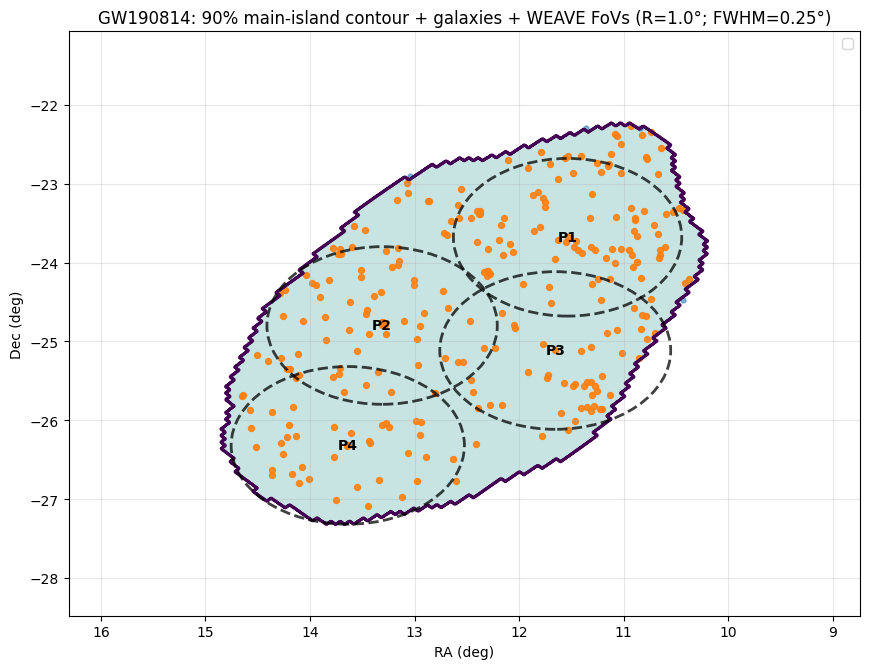

In [14]:
# ============================================================
# ONE CELL: GW190814 90% (main-island) contour + galaxies + WEAVE FoV circles
# - Reads GW190814 skymap (PROB raster)
# - Smooths posterior on the sphere (for prettier contours)
# - Finds the 90% credible MAIN island (largest connected component)
# - Loads galaxy CSV (RA/Dec)
# - Chooses best WEAVE MOS pointings (greedy) with radius=1 deg
# - Plots: 90% contour + galaxies + FoV circles + P1..PN labels
# ============================================================

# ---------- USER SETTINGS ----------
GALAXY_CSV = "galaxy.csv"   # <-- put your CSV filename here
RA_COL = "ra"                 # <-- column name in CSV for RA (deg)
DEC_COL = "dec"               # <-- column name in CSV for Dec (deg)

N_POINTINGS = 4               # <-- how many WEAVE pointings to plot (P1..PN)
WEAVE_RADIUS_DEG = 1.0        # WEAVE MOS radius (deg)

CREDIBLE = 0.90
SMOOTH_FWHM_DEG = 0.25        # try 0.2–0.35 for nicer-looking outlines
PAD_RA_DEG = 1.5              # zoom margin (deg)
PAD_DEC_DEG = 1.2             # zoom margin (deg)

# Plot grid (increase if you want smoother-looking contours; may slow down)
NGRID_RA = 2500
NGRID_DEC = 1200

# ---------- DO NOT EDIT BELOW UNLESS YOU WANT TO ----------
import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

from astropy.io import fits
from astropy.table import Table
import astropy.units as u
from astropy_healpix import HEALPix

import healpy as hp


# ---------- Download skymap ----------
SKYMAP_URL = "https://dcc.ligo.org/LIGO-P2000230/public/GW190814_skymap.fits.gz"
fname = "GW190814_skymap.fits.gz"
if not os.path.exists(fname):
    urllib.request.urlretrieve(SKYMAP_URL, fname)

# ---------- Read skymap (raster PROB) ----------
hdr = fits.getheader(fname, 1)
t = Table.read(fname, hdu=1)

if "PROB" not in t.colnames:
    raise KeyError(f"Expected a raster sky map with PROB column; got columns: {t.colnames}")

ordering = (hdr.get("ORDERING", "NESTED") or "NESTED").strip().upper()
if ordering not in ("NESTED", "RING"):
    ordering = "NESTED"

nside = hdr.get("NSIDE", None)
if nside is None:
    npix = len(t["PROB"])
    nside_guess = int(round(np.sqrt(npix / 12.0)))
    if 12 * nside_guess * nside_guess != npix:
        raise ValueError("Couldn't infer NSIDE from PROB length; header also missing NSIDE.")
    nside = nside_guess

p = np.asarray(t["PROB"], dtype=float)
p = p / p.sum()

print(f"Skymap: NSIDE={nside} ORDERING={ordering}  sum(PROB)={p.sum():.6f}")

# ---------- Smooth posterior on sphere (healpy smoothing expects RING) ----------
if ordering == "NESTED":
    p_ring = hp.reorder(p, n2r=True)
else:
    p_ring = p.copy()

if SMOOTH_FWHM_DEG and SMOOTH_FWHM_DEG > 0:
    fwhm_rad = np.deg2rad(SMOOTH_FWHM_DEG)
    p_ring_s = hp.smoothing(p_ring, fwhm=fwhm_rad, verbose=False)
    p_ring_s = np.clip(p_ring_s, 0, None)
    p_ring_s = p_ring_s / p_ring_s.sum()
else:
    p_ring_s = p_ring

if ordering == "NESTED":
    p_s = hp.reorder(p_ring_s, r2n=True)
else:
    p_s = p_ring_s

# ---------- Credible level per pixel ----------
order_idx = np.argsort(p_s)[::-1]
cum = np.cumsum(p_s[order_idx])
credible = np.empty_like(p_s)
credible[order_idx] = cum

mask90 = credible <= CREDIBLE
mask_pix = np.where(mask90)[0]
print(f"90% region (all islands): pixels={mask_pix.size} mass={p_s[mask90].sum():.6f}")

# ---------- HEALPix helper ----------
hp_ast = HEALPix(nside=nside, order=("nested" if ordering == "NESTED" else "ring"), frame="icrs")

# ---------- Find MAIN island within 90% region (connected components via neighbours) ----------
mask_set = set(mask_pix.tolist())
visited = set()
components = []
components_mass = []

for start in mask_pix:
    s = int(start)
    if s in visited:
        continue
    stack = [s]
    visited.add(s)
    comp = []
    mass = 0.0
    while stack:
        pix = stack.pop()
        comp.append(pix)
        mass += float(p_s[pix])
        neigh = hp_ast.neighbours(pix)  # up to 8 neighbours; -1 means none
        for nb in neigh:
            nb = int(nb)
            if nb >= 0 and nb in mask_set and nb not in visited:
                visited.add(nb)
                stack.append(nb)
    components.append(comp)
    components_mass.append(mass)

components_mass = np.array(components_mass, dtype=float)
main_i = int(np.argmax(components_mass))
main_pix = np.array(components[main_i], dtype=int)

mask_main = np.zeros_like(mask90, dtype=bool)
mask_main[main_pix] = True

print(f"Main island: pixels={main_pix.size} mass={components_mass[main_i]:.6f}")

# ---------- Load galaxies ----------
df = pd.read_csv(GALAXY_CSV)

# tolerant column lookup (case-insensitive)
cols_lower = {c.lower(): c for c in df.columns}
ra_key = cols_lower.get(RA_COL.lower(), RA_COL)
dec_key = cols_lower.get(DEC_COL.lower(), DEC_COL)

if ra_key not in df.columns or dec_key not in df.columns:
    raise KeyError(f"Couldn't find RA/Dec columns. CSV has {list(df.columns)}; tried {RA_COL}/{DEC_COL}.")

gal_ra = df[ra_key].astype(float).to_numpy()
gal_dec = df[dec_key].astype(float).to_numpy()

# Determine which galaxies are inside main island (by HEALPix pixel membership)
gal_pix = hp_ast.lonlat_to_healpix((np.mod(gal_ra, 360.0) * u.deg), (gal_dec * u.deg)).astype(int)
gal_in_main = mask_main[gal_pix]
print(f"Galaxies loaded: {len(gal_ra)}  inside main island 90%: {gal_in_main.sum()}")

# For pointings, we usually target only galaxies inside the main island:
TARGET = np.where(gal_in_main)[0]
target_ra = gal_ra[TARGET]
target_dec = gal_dec[TARGET]

# ---------- Spherical geometry helpers ----------
def radec_to_unitvec(ra_deg, dec_deg):
    ra = np.deg2rad(np.mod(ra_deg, 360.0))
    dec = np.deg2rad(dec_deg)
    cosd = np.cos(dec)
    return np.column_stack([cosd*np.cos(ra), cosd*np.sin(ra), np.sin(dec)])

def angular_sep_deg_matrix(v_centers, v_points):
    dots = np.clip(v_centers @ v_points.T, -1.0, 1.0)
    return np.rad2deg(np.arccos(dots))

# ---------- Candidate pointing centers ----------
# Use target galaxies as candidate centers (fast + works well in practice)
cand_ra = target_ra.copy()
cand_dec = target_dec.copy()

if len(cand_ra) == 0:
    raise RuntimeError("No target galaxies inside the main island. (Check your galaxy list or mask choice.)")

cand_vec = radec_to_unitvec(cand_ra, cand_dec)
tgt_vec = radec_to_unitvec(target_ra, target_dec)

sep = angular_sep_deg_matrix(cand_vec, tgt_vec)  # (Ncand, Ntgt)
cover_matrix = (sep <= WEAVE_RADIUS_DEG)

# ---------- Greedy pointings (max cover of remaining galaxies) ----------
covered = np.zeros(len(TARGET), dtype=bool)
pointings = []

for n in range(1, N_POINTINGS + 1):
    gains = np.sum(cover_matrix & (~covered[None, :]), axis=1)
    best = int(np.argmax(gains))
    best_gain = int(gains[best])
    if best_gain == 0:
        print(f"Stopped at N={n-1}: no further galaxies can be added with radius={WEAVE_RADIUS_DEG}°.")
        break

    newly = cover_matrix[best] & (~covered)
    covered |= cover_matrix[best]

    pointings.append({
        "N": n,
        "ra_deg": float(cand_ra[best]),
        "dec_deg": float(cand_dec[best]),
        "newly_covered": int(newly.sum()),
        "cumulative_covered": int(covered.sum()),
        "cumulative_pct": 100.0 * float(covered.sum()) / float(len(TARGET))
    })

print("\nPointing plan (greedy):")
for pnt in pointings:
    print(f"  P{pnt['N']}: center=({pnt['ra_deg']:.4f}, {pnt['dec_deg']:.4f}) "
          f"+{pnt['newly_covered']:3d}  cum={pnt['cumulative_covered']:3d}/{len(TARGET)} ({pnt['cumulative_pct']:.2f}%)")

# ---------- Zoom window from MAIN island pixels ----------
lon_c, lat_c = hp_ast.healpix_to_lonlat(main_pix)
ra_island = lon_c.to_value(u.deg)   # 0..360
dec_island = lat_c.to_value(u.deg)

def minimal_ra_window(ra_deg, pad_deg):
    ra = np.mod(ra_deg, 360.0)
    ra_sorted = np.sort(ra)
    gaps = np.diff(np.r_[ra_sorted, ra_sorted[0] + 360.0])
    j = np.argmax(gaps)
    start = ra_sorted[(j + 1) % len(ra_sorted)]
    end = ra_sorted[j]
    return (start - pad_deg) % 360.0, (end + pad_deg) % 360.0

def ra_linspace_wrap(ra_min, ra_max, n):
    ra_min %= 360.0; ra_max %= 360.0
    if ra_min <= ra_max:
        return np.linspace(ra_min, ra_max, n)
    a = np.linspace(ra_min, 360.0, n//2, endpoint=False)
    b = np.linspace(0.0, ra_max, n - len(a))
    return np.r_[a, b]

ra_min, ra_max = minimal_ra_window(ra_island, PAD_RA_DEG)
dec_min = float(dec_island.min() - PAD_DEC_DEG)
dec_max = float(dec_island.max() + PAD_DEC_DEG)

wrap = ra_min > ra_max

def shift_ra_for_plot(x_deg):
    """If wrap, shift RA>180 -> RA-360 for a continuous axis; else return as-is."""
    x = np.mod(np.asarray(x_deg, dtype=float), 360.0)
    if not wrap:
        return x
    return np.where(x > 180.0, x - 360.0, x)

# ---------- Build contour grid over zoom window ----------
ra_vals = ra_linspace_wrap(ra_min, ra_max, NGRID_RA) * u.deg
dec_vals = np.linspace(dec_min, dec_max, NGRID_DEC) * u.deg
RA, DEC = np.meshgrid(ra_vals, dec_vals)

grid_pix = hp_ast.lonlat_to_healpix(RA, DEC).astype(int)
Z = credible[grid_pix]  # scalar credible field (from smoothed posterior)

# Convert X coordinates for plotting (handle wrap consistently)
X = shift_ra_for_plot(RA.to_value(u.deg))
gal_ra_plot = shift_ra_for_plot(gal_ra)
p_ra_plot = shift_ra_for_plot([p["ra_deg"] for p in pointings])

# ---------- Plot ----------
fig = plt.figure(figsize=(8.8, 6.8))
ax = fig.add_subplot(111)

# Fill main-island 90% region (as credible<=0.9) and draw contour at 0.9
ax.contourf(X, DEC.to_value(u.deg), Z, levels=[0.0, CREDIBLE], alpha=0.25)
ax.contour(X, DEC.to_value(u.deg), Z, levels=[CREDIBLE], linewidths=2.2, antialiased=True)

# Galaxies: inside main island vs outside (but still in the plot window)
ax.scatter(gal_ra_plot[~gal_in_main], gal_dec[~gal_in_main], s=12, alpha=0.55)
ax.scatter(gal_ra_plot[gal_in_main],  gal_dec[gal_in_main],  s=18, alpha=0.90)

# WEAVE FoV: draw as an ellipse approximation (correct local RA scaling by cos(dec))
for i, pnt in enumerate(pointings):
    ra0 = p_ra_plot[i]
    dec0 = pnt["dec_deg"]
    cosd = np.cos(np.deg2rad(dec0))
    width = 2.0 * WEAVE_RADIUS_DEG / max(cosd, 1e-6)   # RA-deg span for 1° true radius at this Dec
    height = 2.0 * WEAVE_RADIUS_DEG                    # Dec-deg span

    e = Ellipse((ra0, dec0), width=width, height=height,
                fill=False, linestyle="--", linewidth=2, alpha=0.75, zorder=5)
    ax.add_patch(e)
    ax.text(ra0, dec0, f"P{pnt['N']}", ha="center", va="center",
            fontsize=10, weight="bold", zorder=6)

# Axes limits (RA inverted, astronomy convention)
if wrap:
    ra_min_s = shift_ra_for_plot([ra_min])[0]
    ra_max_s = shift_ra_for_plot([ra_max])[0]
    ax.set_xlim(ra_max_s, ra_min_s)
else:
    ax.set_xlim(ra_max, ra_min)

ax.set_ylim(dec_min, dec_max)
ax.set_xlabel("RA (deg)")
ax.set_ylabel("Dec (deg)")
ax.set_title(f"GW190814: 90% main-island contour + galaxies + WEAVE FoVs (R={WEAVE_RADIUS_DEG}°; FWHM={SMOOTH_FWHM_DEG}°)")
ax.grid(True, alpha=0.3)
ax.legend(loc="best")
plt.tight_layout()
plt.show()

Target galaxies inside main island: 269
Candidate centers: 962
Coverage matrix: 962 candidates x 269 galaxies

Independent optimum coverage table:
N=1:  88/269  (32.71%)
N=2: 149/269  (55.39%)
N=3: 201/269  (74.72%)
N=4: 248/269  (92.19%)
N=5: 262/269  (97.40%)
N=6: 269/269  (100.00%)

Chosen centers:

N=1
  P1: (11.5718, -23.4860)

N=2
  P1: (13.3102, -24.7975)
  P2: (11.5718, -23.4860)

N=3
  P1: (11.5718, -25.2860)
  P2: (11.5718, -23.4860)
  P3: (13.5218, -24.6860)

N=4
  P1: (11.6543, -25.1149)
  P2: (13.1530, -23.9784)
  P3: (11.2718, -23.1860)
  P4: (13.6718, -26.0360)

N=5
  P1: (13.4242, -26.2845)
  P2: (11.6543, -25.1149)
  P3: (11.2718, -23.1860)
  P4: (13.0718, -23.9360)
  P5: (13.9718, -25.2860)

N=6
  P1: (13.4242, -26.2845)
  P2: (11.2150, -22.8550)
  P3: (14.2728, -25.2068)
  P4: (11.4218, -24.3860)
  P5: (12.0218, -25.4360)
  P6: (13.0718, -23.9360)


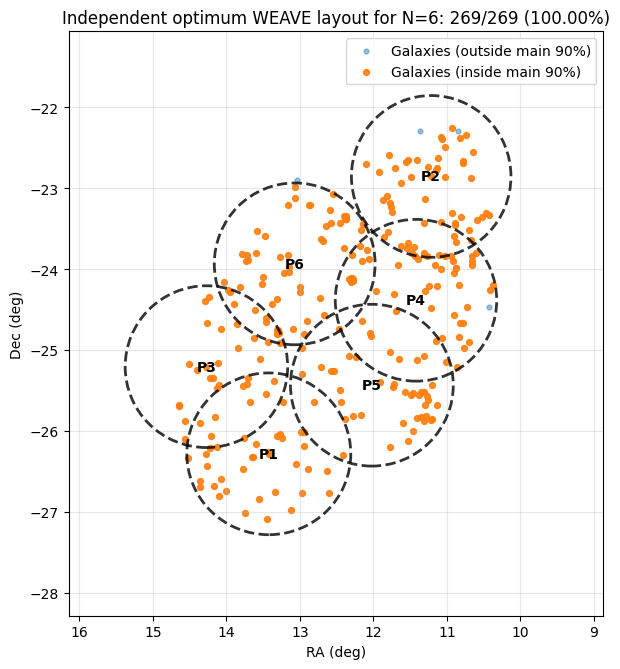

In [35]:
# ============================================================
# INDEPENDENT optimum for each N using integer programming
# Assumes these already exist from your previous cell:
#   gal_ra, gal_dec, gal_in_main, mask_main, hp_ast, WEAVE_RADIUS_DEG
# ============================================================

# ---------- SETTINGS ----------
N_MAX = 6          # solve independently for N = 1..N_MAX
N_PLOT = 6        # which N to plot
GRID_STEP = 0.15   # deg; 0.10 is denser/slower, 0.15 is a good start
PAD_RA = 0.3       # extra margin for candidate grid
PAD_DEC = 0.3

# ---------- install/import PuLP if needed ----------
import sys, subprocess
try:
    import pulp
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "pulp"])
    import pulp

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import astropy.units as u

# ---------- sanity check ----------
required = ["gal_ra", "gal_dec", "gal_in_main", "mask_main", "hp_ast", "WEAVE_RADIUS_DEG"]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(f"Missing variables from previous cell: {missing}")

# ---------- target galaxies: inside main island ----------
target_idx = np.where(gal_in_main)[0]
target_ra = np.asarray(gal_ra[target_idx], dtype=float)
target_dec = np.asarray(gal_dec[target_idx], dtype=float)

if len(target_ra) == 0:
    raise RuntimeError("No galaxies inside main island.")

print(f"Target galaxies inside main island: {len(target_ra)}")

# ---------- helpers ----------
def radec_to_unitvec(ra_deg, dec_deg):
    ra = np.deg2rad(np.mod(np.asarray(ra_deg, dtype=float), 360.0))
    dec = np.deg2rad(np.asarray(dec_deg, dtype=float))
    cosd = np.cos(dec)
    return np.column_stack([cosd*np.cos(ra), cosd*np.sin(ra), np.sin(dec)])

def angular_sep_deg_matrix(v_centers, v_points):
    dots = np.clip(v_centers @ v_points.T, -1.0, 1.0)
    return np.rad2deg(np.arccos(dots))

def center_in_main_island(ra_deg, dec_deg):
    pix = hp_ast.lonlat_to_healpix((np.mod(ra_deg, 360.0) * u.deg), (dec_deg * u.deg))
    return bool(mask_main[int(pix)])

def shift_ra_for_plot(x_deg, wrap):
    x = np.mod(np.asarray(x_deg, dtype=float), 360.0)
    if not wrap:
        return x
    return np.where(x > 180.0, x - 360.0, x)

def minimal_ra_window(ra_deg, pad_deg):
    ra = np.mod(np.asarray(ra_deg, dtype=float), 360.0)
    ra_sorted = np.sort(ra)
    gaps = np.diff(np.r_[ra_sorted, ra_sorted[0] + 360.0])
    j = np.argmax(gaps)
    start = ra_sorted[(j + 1) % len(ra_sorted)]
    end = ra_sorted[j]
    return (start - pad_deg) % 360.0, (end + pad_deg) % 360.0

# ---------- candidate centers ----------
# 1) all target galaxy positions
cand_ra = list(target_ra.copy())
cand_dec = list(target_dec.copy())

# 2) regular grid inside main island bounding box
ra_min_raw, ra_max_raw = minimal_ra_window(target_ra, PAD_RA)
dec_min = float(target_dec.min() - PAD_DEC)
dec_max = float(target_dec.max() + PAD_DEC)

# unwrap RA interval for grid building
ra_unwrapped = np.mod(target_ra, 360.0)
ra_sorted = np.sort(ra_unwrapped)
gaps = np.diff(np.r_[ra_sorted, ra_sorted[0] + 360.0])
j = np.argmax(gaps)
start = ra_sorted[(j + 1) % len(ra_sorted)]
end = ra_sorted[j]
if end < start:
    end += 360.0

ra_grid = np.arange(start - PAD_RA, end + PAD_RA + 0.5*GRID_STEP, GRID_STEP)
dec_grid = np.arange(dec_min, dec_max + 0.5*GRID_STEP, GRID_STEP)

for ra in ra_grid:
    for dec in dec_grid:
        ra_mod = ra % 360.0
        if center_in_main_island(ra_mod, dec):
            cand_ra.append(ra_mod)
            cand_dec.append(dec)

cand_ra = np.asarray(cand_ra, dtype=float)
cand_dec = np.asarray(cand_dec, dtype=float)

# deduplicate approximately
cand_key = np.round(np.column_stack([cand_ra, cand_dec]), 4)
_, uniq_idx = np.unique(cand_key, axis=0, return_index=True)
cand_ra = cand_ra[np.sort(uniq_idx)]
cand_dec = cand_dec[np.sort(uniq_idx)]

print(f"Candidate centers: {len(cand_ra)}")

# ---------- coverage matrix ----------
cand_vec = radec_to_unitvec(cand_ra, cand_dec)
tgt_vec = radec_to_unitvec(target_ra, target_dec)
sep = angular_sep_deg_matrix(cand_vec, tgt_vec)
A = (sep <= WEAVE_RADIUS_DEG).astype(np.uint8)   # shape = (Ncand, Ntarget)

Ncand, Ntarget = A.shape
print(f"Coverage matrix: {Ncand} candidates x {Ntarget} galaxies")

# ---------- solve independently for each N ----------
solutions = {}

for N in range(1, N_MAX + 1):
    prob = pulp.LpProblem(f"weave_maxcover_N{N}", pulp.LpMaximize)

    x = [pulp.LpVariable(f"x_{i}", cat="Binary") for i in range(Ncand)]   # candidate selected?
    y = [pulp.LpVariable(f"y_{j}", cat="Binary") for j in range(Ntarget)] # galaxy covered?

    # objective: maximize covered galaxies
    prob += pulp.lpSum(y)

    # choose at most N fields
    prob += pulp.lpSum(x) <= N

    # galaxy j can be covered only if at least one selected field covers it
    for j in range(Ntarget):
        covering_i = np.where(A[:, j] == 1)[0]
        if len(covering_i) == 0:
            prob += y[j] == 0
        else:
            prob += y[j] <= pulp.lpSum(x[i] for i in covering_i)

    # solve
    solver = pulp.PULP_CBC_CMD(msg=False)
    result_status = prob.solve(solver)

    if pulp.LpStatus[result_status] not in ("Optimal", "Integer Feasible"):
        print(f"N={N}: solver status = {pulp.LpStatus[result_status]}")

    chosen = np.array([i for i in range(Ncand) if pulp.value(x[i]) > 0.5], dtype=int)
    covered = np.array([j for j in range(Ntarget) if pulp.value(y[j]) > 0.5], dtype=int)

    solutions[N] = {
        "chosen_idx": chosen,
        "covered_idx": covered,
        "n_covered": len(covered),
        "pct": 100.0 * len(covered) / Ntarget,
        "centers_ra": cand_ra[chosen],
        "centers_dec": cand_dec[chosen],
    }

# ---------- report ----------
print("\nIndependent optimum coverage table:")
for N in range(1, N_MAX + 1):
    sol = solutions[N]
    print(f"N={N}: {sol['n_covered']:3d}/{Ntarget}  ({sol['pct']:.2f}%)")

print("\nChosen centers:")
for N in range(1, N_MAX + 1):
    sol = solutions[N]
    print(f"\nN={N}")
    for k, (ra, dec) in enumerate(zip(sol["centers_ra"], sol["centers_dec"]), start=1):
        print(f"  P{k}: ({ra:.4f}, {dec:.4f})")

# ---------- plot chosen N ----------
if N_PLOT not in solutions:
    raise RuntimeError(f"N_PLOT={N_PLOT} not solved.")

sol = solutions[N_PLOT]
plot_ra = sol["centers_ra"]
plot_dec = sol["centers_dec"]

# zoom window from target galaxies
ra_min_plot, ra_max_plot = minimal_ra_window(target_ra, 1.5)
dec_min_plot = float(target_dec.min() - 1.2)
dec_max_plot = float(target_dec.max() + 1.2)
wrap = ra_min_plot > ra_max_plot

gal_ra_plot = shift_ra_for_plot(gal_ra, wrap)
plot_ra_shift = shift_ra_for_plot(plot_ra, wrap)

fig = plt.figure(figsize=(8.8, 6.8))
ax = fig.add_subplot(111)

# galaxies
ax.scatter(gal_ra_plot[~gal_in_main], gal_dec[~gal_in_main], s=12, alpha=0.45, label="Galaxies (outside main 90%)")
ax.scatter(gal_ra_plot[gal_in_main],  gal_dec[gal_in_main],  s=18, alpha=0.90, label="Galaxies (inside main 90%)")

# FoV ellipses
for i, (ra0, dec0) in enumerate(zip(plot_ra_shift, plot_dec), start=1):
    cosd = np.cos(np.deg2rad(dec0))
    width = 2.0 * WEAVE_RADIUS_DEG / max(cosd, 1e-6)
    height = 2.0 * WEAVE_RADIUS_DEG
    e = Ellipse((ra0, dec0), width=width, height=height,
                fill=False, linestyle="--", linewidth=2, alpha=0.8, zorder=5)
    ax.add_patch(e)
    ax.text(ra0, dec0, f"P{i}", ha="center", va="center", fontsize=10, weight="bold", zorder=6)

# limits
if wrap:
    ra_min_s = shift_ra_for_plot([ra_min_plot], True)[0]
    ra_max_s = shift_ra_for_plot([ra_max_plot], True)[0]
    ax.set_xlim(ra_max_s, ra_min_s)
else:
    ax.set_xlim(ra_max_plot, ra_min_plot)

ax.set_ylim(dec_min_plot, dec_max_plot)
ax.set_xlabel("RA (deg)")
ax.set_ylabel("Dec (deg)")
ax.set_title(f"Independent optimum WEAVE layout for N={N_PLOT}: {sol['n_covered']}/{Ntarget} ({sol['pct']:.2f}%)")
ax.grid(True, alpha=0.3)
ax.legend(loc="best")

# optional sky-angle aspect correction
dec0 = 0.5 * (dec_min_plot + dec_max_plot)
ax.set_aspect(1.0 / np.cos(np.deg2rad(dec0)), adjustable="box")

plt.tight_layout()
plt.show()

/tmp/ipykernel_472/3272041241.py:121: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="best")


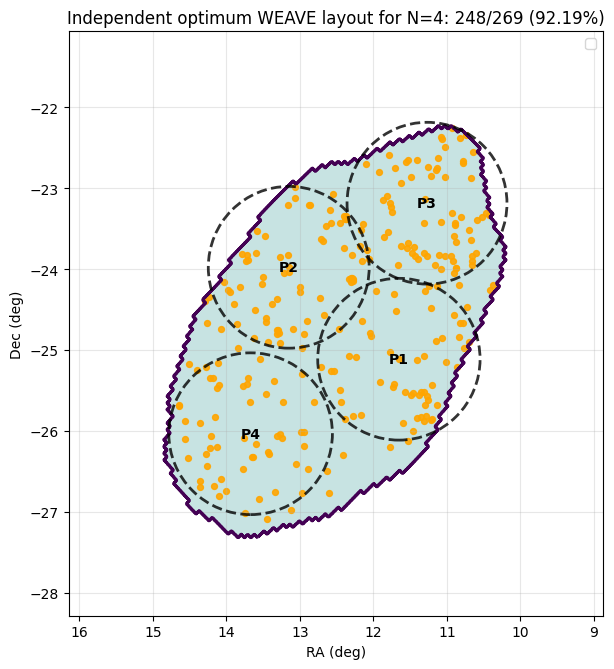

In [31]:
# ============================================================
# PLOT: 90% main-island contour + inside galaxies only + independent-optimum WEAVE circles
# Run this AFTER the independent-optimisation cell
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import astropy.units as u

# ---------- sanity check ----------
required = ["solutions", "N_PLOT", "target_ra", "target_dec", "credible", "hp_ast", "CREDIBLE", "WEAVE_RADIUS_DEG"]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(f"Missing variables from previous cells: {missing}")

if N_PLOT not in solutions:
    raise RuntimeError(f"N_PLOT={N_PLOT} not found in solutions. Available: {list(solutions.keys())}")

sol = solutions[N_PLOT]
plot_ra = np.asarray(sol["centers_ra"], dtype=float)
plot_dec = np.asarray(sol["centers_dec"], dtype=float)

# ---------- helpers ----------
def minimal_ra_window(ra_deg, pad_deg):
    ra = np.mod(np.asarray(ra_deg, dtype=float), 360.0)
    ra_sorted = np.sort(ra)
    gaps = np.diff(np.r_[ra_sorted, ra_sorted[0] + 360.0])
    j = np.argmax(gaps)
    start = ra_sorted[(j + 1) % len(ra_sorted)]
    end = ra_sorted[j]
    return (start - pad_deg) % 360.0, (end + pad_deg) % 360.0

def ra_linspace_wrap(ra_min, ra_max, n):
    ra_min %= 360.0
    ra_max %= 360.0
    if ra_min <= ra_max:
        return np.linspace(ra_min, ra_max, n)
    a = np.linspace(ra_min, 360.0, n // 2, endpoint=False)
    b = np.linspace(0.0, ra_max, n - len(a))
    return np.r_[a, b]

def shift_ra_for_plot(x_deg, wrap):
    x = np.mod(np.asarray(x_deg, dtype=float), 360.0)
    if not wrap:
        return x
    return np.where(x > 180.0, x - 360.0, x)

# ---------- zoom window from INSIDE galaxies only ----------
PAD_RA_PLOT = 1.5
PAD_DEC_PLOT = 1.2
NGRID_RA_PLOT = 2500
NGRID_DEC_PLOT = 1200

ra_min_plot, ra_max_plot = minimal_ra_window(target_ra, PAD_RA_PLOT)
dec_min_plot = float(np.min(target_dec) - PAD_DEC_PLOT)
dec_max_plot = float(np.max(target_dec) + PAD_DEC_PLOT)
wrap = ra_min_plot > ra_max_plot

# ---------- rebuild contour grid ----------
ra_vals = ra_linspace_wrap(ra_min_plot, ra_max_plot, NGRID_RA_PLOT) * u.deg
dec_vals = np.linspace(dec_min_plot, dec_max_plot, NGRID_DEC_PLOT) * u.deg
RA, DEC = np.meshgrid(ra_vals, dec_vals)

grid_pix = hp_ast.lonlat_to_healpix(RA, DEC).astype(int)
Z = credible[grid_pix]

X = shift_ra_for_plot(RA.to_value(u.deg), wrap)
target_ra_plot = shift_ra_for_plot(target_ra, wrap)
plot_ra_shift = shift_ra_for_plot(plot_ra, wrap)

# ---------- plot ----------
fig = plt.figure(figsize=(8.8, 6.8))
ax = fig.add_subplot(111)

# 90% contour/fill
ax.contourf(X, DEC.to_value(u.deg), Z, levels=[0.0, CREDIBLE], alpha=0.25)
ax.contour(X, DEC.to_value(u.deg), Z, levels=[CREDIBLE], linewidths=2.2, antialiased=True)

# ONLY galaxies inside the main island
ax.scatter(target_ra_plot, target_dec, s=18, alpha=0.90, color="orange")

# WEAVE FoV ellipses
for i, (ra0, dec0) in enumerate(zip(plot_ra_shift, plot_dec), start=1):
    cosd = np.cos(np.deg2rad(dec0))
    width = 2.0 * WEAVE_RADIUS_DEG / max(cosd, 1e-6)
    height = 2.0 * WEAVE_RADIUS_DEG

    e = Ellipse(
        (ra0, dec0),
        width=width,
        height=height,
        fill=False,
        linestyle="--",
        linewidth=2,
        alpha=0.8,
        zorder=5
    )
    ax.add_patch(e)

    ax.text(
        ra0, dec0, f"P{i}",
        ha="center", va="center",
        fontsize=10, weight="bold",
        zorder=6
    )

# axes
if wrap:
    ra_min_s = shift_ra_for_plot([ra_min_plot], True)[0]
    ra_max_s = shift_ra_for_plot([ra_max_plot], True)[0]
    ax.set_xlim(ra_max_s, ra_min_s)
else:
    ax.set_xlim(ra_max_plot, ra_min_plot)

ax.set_ylim(dec_min_plot, dec_max_plot)
ax.set_xlabel("RA (deg)")
ax.set_ylabel("Dec (deg)")
ax.set_title(f"Independent optimum WEAVE layout for N={N_PLOT}: {sol['n_covered']}/{len(target_ra)} ({sol['pct']:.2f}%)")
ax.grid(True, alpha=0.3)
ax.legend(loc="best")

# sky-angle aspect correction
dec0 = 0.5 * (dec_min_plot + dec_max_plot)
ax.set_aspect(1.0 / np.cos(np.deg2rad(dec0)), adjustable="box")

plt.tight_layout()
plt.show()

In [17]:
from astropy.coordinates import SkyCoord
import astropy.units as u
import numpy as np

# galaxy coordinates
coords = SkyCoord(ra=target_ra*u.deg, dec=target_dec*u.deg)

# pairwise separations
sep = coords[:,None].separation(coords[None,:])

# ignore self-separation
sep = sep.value
sep[sep == 0] = np.nan

# fibre collision threshold (arcsec)
limit = 30 / 3600  # deg

collisions = np.where(sep < limit)

print("Possible fibre collisions:", len(collisions[0])//2)

Possible fibre collisions: 3


In [18]:
from astropy.coordinates import SkyCoord
import astropy.units as u
import numpy as np
import pandas as pd

# --- inputs ---
# target_ra, target_dec = galaxies inside the main island
# If you want the full catalog instead, replace with gal_ra, gal_dec
coords = SkyCoord(ra=target_ra * u.deg, dec=target_dec * u.deg)

# fibre collision threshold
limit_arcsec = 30.0
limit = limit_arcsec * u.arcsec

# pairwise separations
sep = coords[:, None].separation(coords[None, :])

# keep only unique pairs i < j
i_idx, j_idx = np.triu_indices(len(coords), k=1)
close = sep[i_idx, j_idx] < limit

i_close = i_idx[close]
j_close = j_idx[close]
sep_close = sep[i_close, j_close].to(u.arcsec).value

# build table
collisions_df = pd.DataFrame({
    "i": i_close,
    "j": j_close,
    "ra_i_deg": target_ra[i_close],
    "dec_i_deg": target_dec[i_close],
    "ra_j_deg": target_ra[j_close],
    "dec_j_deg": target_dec[j_close],
    "sep_arcsec": sep_close
}).sort_values("sep_arcsec").reset_index(drop=True)

print(f"Possible fibre-collision pairs: {len(collisions_df)}")
display(collisions_df)

Possible fibre-collision pairs: 3


,i,j,ra_i_deg,dec_i_deg,ra_j_deg,dec_j_deg,sep_arcsec
0,128,129,10.871539,-23.990892,10.871868,-23.989514,5.077445
1,115,116,13.305139,-24.752335,13.308348,-24.749975,13.499850
2,208,209,12.377014,-23.385117,12.385618,-23.383007,29.427577


Solver status: Optimal

Selected 6 pointings:
  P1: (11.2718, -23.1860)
  P2: (11.4218, -24.3860)
  P3: (12.1718, -25.8860)
  P4: (13.0718, -23.9360)
  P5: (13.5218, -24.8360)
  P6: (13.8218, -26.3360)

Close-pair splittability:
Pair 1: galaxies (128,129) -> split=True
   galaxy 128 covered by pointings [1, 2]
   galaxy 129 covered by pointings [1, 2]
   union of covering pointings = [1, 2]
Pair 2: galaxies (115,116) -> split=True
   galaxy 115 covered by pointings [4, 5]
   galaxy 116 covered by pointings [4, 5]
   union of covering pointings = [4, 5]
Pair 3: galaxies (208,209) -> split=False
   galaxy 208 covered by pointings [4]
   galaxy 209 covered by pointings [4]
   union of covering pointings = [4]

Coverage check: 269/269 = 100.00%


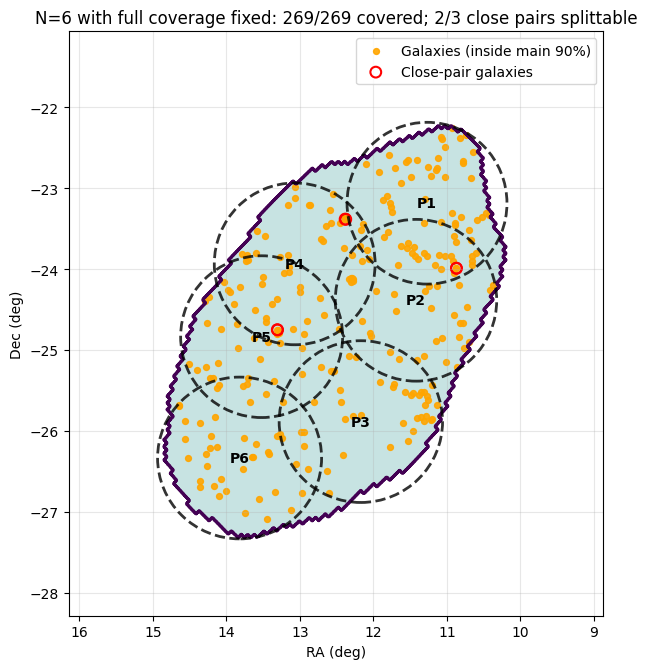

In [19]:
# ============================================================
# SECOND-STAGE OPTIMIZATION:
# Keep N=6 and 100% galaxy coverage fixed, and try to make
# close fibre-collision pairs splittable across different pointings.
# ============================================================

# ---------- SETTINGS ----------
N_FIX = 6
close_pairs = [
    (128, 129),   # 5 arcsec
    (115, 116),   # 13 arcsec
    (208, 209),   # 29.4 arcsec
]

# ---------- imports ----------
import sys, subprocess
try:
    import pulp
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "pulp"])
    import pulp

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import astropy.units as u

# ---------- sanity checks ----------
required = ["A", "cand_ra", "cand_dec", "target_ra", "target_dec", "credible", "hp_ast", "CREDIBLE", "WEAVE_RADIUS_DEG"]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(f"Missing variables from previous cells: {missing}")

Ncand, Ntarget = A.shape
if N_FIX > 20:
    print("Just checking: N_FIX is large; this may take longer than expected.")

for i, j in close_pairs:
    if i < 0 or i >= Ntarget or j < 0 or j >= Ntarget:
        raise ValueError(f"Close pair ({i},{j}) is outside target galaxy index range 0..{Ntarget-1}")

# ---------- optimization ----------
# x_i = candidate pointing selected?
# s_k = close pair k is splittable across >=2 selected pointings?
prob = pulp.LpProblem("weave_pair_split_secondary", pulp.LpMaximize)

x = [pulp.LpVariable(f"x_{i}", cat="Binary") for i in range(Ncand)]
s = [pulp.LpVariable(f"s_{k}", cat="Binary") for k in range(len(close_pairs))]

# Exactly N_FIX pointings
prob += pulp.lpSum(x) == N_FIX

# Full coverage of all target galaxies
for j in range(Ntarget):
    covering_i = np.where(A[:, j] == 1)[0]
    if len(covering_i) == 0:
        raise RuntimeError(f"Target galaxy {j} is not coverable by any candidate center.")
    prob += pulp.lpSum(x[i] for i in covering_i) >= 1

# A close pair is "splittable" if the union of selected pointings that cover either member has size >= 2.
# That is enough to allow one galaxy to be assigned in one selected pointing and the other in another.
pair_union_sizes = []
for k, (g1, g2) in enumerate(close_pairs):
    union_i = np.where((A[:, g1] == 1) | (A[:, g2] == 1))[0]
    pair_union_sizes.append(union_i)
    prob += pulp.lpSum(x[i] for i in union_i) >= 2 * s[k]

# Objective:
# First maximize number of splittable close pairs.
# Then mildly prefer more redundant coverage (tie-breaker only).
redundancy_terms = []
for j in range(Ntarget):
    covering_i = np.where(A[:, j] == 1)[0]
    redundancy_terms.append(pulp.lpSum(x[i] for i in covering_i))

prob += 1000 * pulp.lpSum(s) + 0.01 * pulp.lpSum(redundancy_terms)

solver = pulp.PULP_CBC_CMD(msg=False)
status = prob.solve(solver)
print("Solver status:", pulp.LpStatus[status])

chosen = np.array([i for i in range(Ncand) if pulp.value(x[i]) > 0.5], dtype=int)
split_flags = np.array([int(round(pulp.value(v))) for v in s], dtype=int)

sel_ra = cand_ra[chosen]
sel_dec = cand_dec[chosen]

print(f"\nSelected {len(chosen)} pointings:")
for n, (ra, dec) in enumerate(zip(sel_ra, sel_dec), start=1):
    print(f"  P{n}: ({ra:.4f}, {dec:.4f})")

# ---------- report close-pair status ----------
print("\nClose-pair splittability:")
for k, ((g1, g2), flag) in enumerate(zip(close_pairs, split_flags), start=1):
    cover_g1 = [idx+1 for idx, ci in enumerate(chosen) if A[ci, g1] == 1]
    cover_g2 = [idx+1 for idx, ci in enumerate(chosen) if A[ci, g2] == 1]
    union_cover = sorted(set(cover_g1) | set(cover_g2))
    print(f"Pair {k}: galaxies ({g1},{g2}) -> split={bool(flag)}")
    print(f"   galaxy {g1} covered by pointings {cover_g1}")
    print(f"   galaxy {g2} covered by pointings {cover_g2}")
    print(f"   union of covering pointings = {union_cover}")

# ---------- verify full coverage ----------
covered = np.any(A[chosen, :] == 1, axis=0)
ncovered = int(covered.sum())
print(f"\nCoverage check: {ncovered}/{Ntarget} = {100*ncovered/Ntarget:.2f}%")

# ---------- plotting helpers ----------
def minimal_ra_window(ra_deg, pad_deg):
    ra = np.mod(np.asarray(ra_deg, dtype=float), 360.0)
    ra_sorted = np.sort(ra)
    gaps = np.diff(np.r_[ra_sorted, ra_sorted[0] + 360.0])
    j = np.argmax(gaps)
    start = ra_sorted[(j + 1) % len(ra_sorted)]
    end = ra_sorted[j]
    return (start - pad_deg) % 360.0, (end + pad_deg) % 360.0

def ra_linspace_wrap(ra_min, ra_max, n):
    ra_min %= 360.0
    ra_max %= 360.0
    if ra_min <= ra_max:
        return np.linspace(ra_min, ra_max, n)
    a = np.linspace(ra_min, 360.0, n // 2, endpoint=False)
    b = np.linspace(0.0, ra_max, n - len(a))
    return np.r_[a, b]

def shift_ra_for_plot(x_deg, wrap):
    x = np.mod(np.asarray(x_deg, dtype=float), 360.0)
    if not wrap:
        return x
    return np.where(x > 180.0, x - 360.0, x)

# ---------- rebuild 90% contour plot ----------
PAD_RA_PLOT = 1.5
PAD_DEC_PLOT = 1.2
NGRID_RA_PLOT = 2500
NGRID_DEC_PLOT = 1200

ra_min_plot, ra_max_plot = minimal_ra_window(target_ra, PAD_RA_PLOT)
dec_min_plot = float(np.min(target_dec) - PAD_DEC_PLOT)
dec_max_plot = float(np.max(target_dec) + PAD_DEC_PLOT)
wrap = ra_min_plot > ra_max_plot

ra_vals = ra_linspace_wrap(ra_min_plot, ra_max_plot, NGRID_RA_PLOT) * u.deg
dec_vals = np.linspace(dec_min_plot, dec_max_plot, NGRID_DEC_PLOT) * u.deg
RA, DEC = np.meshgrid(ra_vals, dec_vals)

grid_pix = hp_ast.lonlat_to_healpix(RA, DEC).astype(int)
Z = credible[grid_pix]

X = shift_ra_for_plot(RA.to_value(u.deg), wrap)
target_ra_plot = shift_ra_for_plot(target_ra, wrap)
sel_ra_plot = shift_ra_for_plot(sel_ra, wrap)

# ---------- plot ----------
fig = plt.figure(figsize=(8.8, 6.8))
ax = fig.add_subplot(111)

ax.contourf(X, DEC.to_value(u.deg), Z, levels=[0.0, CREDIBLE], alpha=0.25)
ax.contour(X, DEC.to_value(u.deg), Z, levels=[CREDIBLE], linewidths=2.2, antialiased=True)

# galaxies inside main island only
ax.scatter(target_ra_plot, target_dec, s=18, alpha=0.90, color="orange", label="Galaxies (inside main 90%)")

# highlight the close-pair galaxies
pair_gals = sorted(set([g for pair in close_pairs for g in pair]))
ax.scatter(
    target_ra_plot[pair_gals],
    target_dec[pair_gals],
    s=60,
    facecolors="none",
    edgecolors="red",
    linewidths=1.5,
    label="Close-pair galaxies"
)

# selected WEAVE fields
for i, (ra0, dec0) in enumerate(zip(sel_ra_plot, sel_dec), start=1):
    cosd = np.cos(np.deg2rad(dec0))
    width = 2.0 * WEAVE_RADIUS_DEG / max(cosd, 1e-6)
    height = 2.0 * WEAVE_RADIUS_DEG
    e = Ellipse(
        (ra0, dec0),
        width=width,
        height=height,
        fill=False,
        linestyle="--",
        linewidth=2,
        alpha=0.8,
        zorder=5
    )
    ax.add_patch(e)
    ax.text(ra0, dec0, f"P{i}", ha="center", va="center", fontsize=10, weight="bold", zorder=6)

if wrap:
    ra_min_s = shift_ra_for_plot([ra_min_plot], True)[0]
    ra_max_s = shift_ra_for_plot([ra_max_plot], True)[0]
    ax.set_xlim(ra_max_s, ra_min_s)
else:
    ax.set_xlim(ra_max_plot, ra_min_plot)

ax.set_ylim(dec_min_plot, dec_max_plot)
ax.set_xlabel("RA (deg)")
ax.set_ylabel("Dec (deg)")
ax.set_title(
    f"N={N_FIX} with full coverage fixed: {ncovered}/{Ntarget} covered; "
    f"{split_flags.sum()}/{len(close_pairs)} close pairs splittable"
)
ax.grid(True, alpha=0.3)
ax.legend(loc="best")

dec0 = 0.5 * (dec_min_plot + dec_max_plot)
ax.set_aspect(1.0 / np.cos(np.deg2rad(dec0)), adjustable="box")

plt.tight_layout()
plt.show()

In [21]:
pixel_area_sr = 4 * np.pi / (12 * nside**2)
pixel_area_deg2 = pixel_area_sr * (180/np.pi)**2

main_island_area = len(main_pix) * pixel_area_deg2
print(main_island_area)

14.07783950209668


In [22]:
from astropy.coordinates import SkyCoord
import astropy.units as u
import numpy as np
import pandas as pd

# --------------------------------------------------
# Assumes these already exist from your earlier cells:
#   target_ra, target_dec          # galaxies inside main island
#   target_idx                     # indices back to original catalog
# --------------------------------------------------

limit_arcsec = 60.0
limit = limit_arcsec * u.arcsec

coords = SkyCoord(ra=target_ra * u.deg, dec=target_dec * u.deg)

# Pairwise separations
sep = coords[:, None].separation(coords[None, :])

# Keep only unique pairs i < j
i_idx, j_idx = np.triu_indices(len(coords), k=1)
close = sep[i_idx, j_idx] < limit

i_close = i_idx[close]
j_close = j_idx[close]
sep_close = sep[i_close, j_close].to(u.arcsec).value

collisions_df = pd.DataFrame({
    "target_i": i_close,
    "target_j": j_close,
    "catalog_i": target_idx[i_close],
    "catalog_j": target_idx[j_close],
    "ra_i_deg": target_ra[i_close],
    "dec_i_deg": target_dec[i_close],
    "ra_j_deg": target_ra[j_close],
    "dec_j_deg": target_dec[j_close],
    "sep_arcsec": sep_close
}).sort_values("sep_arcsec").reset_index(drop=True)

print(f"Possible fibre-collision pairs (< {limit_arcsec:.0f} arcsec): {len(collisions_df)}")
display(collisions_df)

Possible fibre-collision pairs (< 60 arcsec): 10


,target_i,target_j,catalog_i,catalog_j,ra_i_deg,dec_i_deg,ra_j_deg,dec_j_deg,sep_arcsec
0,128,129,129,130,10.871539,-23.990892,10.871868,-23.989514,5.077445
1,115,116,116,117,13.305139,-24.752335,13.308348,-24.749975,13.499850
2,208,209,209,210,12.377014,-23.385117,12.385618,-23.383007,29.427577
3,20,21,20,21,13.638500,-26.318483,13.648524,-26.322521,35.461717
4,208,210,209,211,12.377014,-23.385117,12.370019,-23.375956,40.273124
5,216,217,217,218,12.859176,-23.213492,12.872412,-23.213535,43.792276
6,254,255,258,259,14.648920,-25.690442,14.641122,-25.677270,53.745970
7,141,143,142,144,12.310945,-24.111322,12.295779,-24.104922,54.903626
8,209,210,210,211,12.385618,-23.383007,12.370019,-23.375956,57.456893
9,139,140,140,141,12.282332,-24.144983,12.284519,-24.128852,58.514381


In [23]:
import pandas as pd

# Assumes these already exist:
#   collisions_df
#   solutions
#   N_PLOT
#   A

sol = solutions[N_PLOT]
chosen_idx = sol["chosen_idx"]

rows = []
splittable_count = 0

for _, row in collisions_df.iterrows():
    gi = int(row["target_i"])
    gj = int(row["target_j"])

    # Which selected pointings cover each galaxy?
    cover_i = [k+1 for k, ci in enumerate(chosen_idx) if A[ci, gi] == 1]
    cover_j = [k+1 for k, ci in enumerate(chosen_idx) if A[ci, gj] == 1]

    union_cover = sorted(set(cover_i) | set(cover_j))
    shared_cover = sorted(set(cover_i) & set(cover_j))

    # Splittable if the union contains at least two distinct selected pointings
    splittable = len(union_cover) >= 2
    splittable_count += int(splittable)

    rows.append({
        "target_i": gi,
        "target_j": gj,
        "sep_arcsec": row["sep_arcsec"],
        "pointings_i": cover_i,
        "pointings_j": cover_j,
        "shared_pointings": shared_cover,
        "union_pointings": union_cover,
        "splittable": splittable
    })

split_df = pd.DataFrame(rows).sort_values("sep_arcsec").reset_index(drop=True)

print(f"Splittable close pairs in current N={N_PLOT} layout: {splittable_count}/{len(split_df)}")
display(split_df)

Splittable close pairs in current N=4 layout: 0/10


,target_i,target_j,sep_arcsec,pointings_i,pointings_j,shared_pointings,union_pointings,splittable
0,128,129,5.077445,[3],[3],[3],[3],False
1,115,116,13.499850,[2],[2],[2],[2],False
2,208,209,29.427577,[2],[2],[2],[2],False
3,20,21,35.461717,[4],[4],[4],[4],False
4,208,210,40.273124,[2],[2],[2],[2],False
5,216,217,43.792276,[2],[2],[2],[2],False
6,254,255,53.745970,[4],[4],[4],[4],False
7,141,143,54.903626,[2],[2],[2],[2],False
8,209,210,57.456893,[2],[2],[2],[2],False
9,139,140,58.514381,[2],[2],[2],[2],False


In [26]:
sol = solutions[N_PLOT]
pointing_ra = np.asarray(sol["centers_ra"], dtype=float)
pointing_dec = np.asarray(sol["centers_dec"], dtype=float)

In [28]:
import numpy as np
import pandas as pd
from astropy.coordinates import SkyCoord
import astropy.units as u

# --------------------------------------------------
# CHOOSE WHICH LAYOUT TO TEST
# --------------------------------------------------

# Option A: overlap-optimized layout from your later cell
pointing_ra = np.asarray(sel_ra, dtype=float)
pointing_dec = np.asarray(sel_dec, dtype=float)


# --------------------------------------------------
# Inputs assumed to already exist:
#   collisions_df   (from your 60 arcsec search)
#   target_ra, target_dec
#   WEAVE_RADIUS_DEG
# --------------------------------------------------

# Build coordinates
gal_coords = SkyCoord(ra=target_ra * u.deg, dec=target_dec * u.deg)
ptg_coords = SkyCoord(ra=pointing_ra * u.deg, dec=pointing_dec * u.deg)

rows = []
splittable_count = 0

for _, row in collisions_df.iterrows():
    gi = int(row["target_i"])
    gj = int(row["target_j"])

    # separations from each galaxy to each pointing centre
    sep_i = gal_coords[gi].separation(ptg_coords).deg
    sep_j = gal_coords[gj].separation(ptg_coords).deg

    # which selected pointings cover each galaxy?
    cover_i = [k+1 for k in range(len(ptg_coords)) if sep_i[k] <= WEAVE_RADIUS_DEG]
    cover_j = [k+1 for k in range(len(ptg_coords)) if sep_j[k] <= WEAVE_RADIUS_DEG]

    union_cover = sorted(set(cover_i) | set(cover_j))
    shared_cover = sorted(set(cover_i) & set(cover_j))

    # splittable if there exist at least two distinct pointings among the union
    splittable = len(union_cover) >= 2
    splittable_count += int(splittable)

    rows.append({
        "target_i": gi,
        "target_j": gj,
        "sep_arcsec": row["sep_arcsec"],
        "pointings_i": cover_i,
        "pointings_j": cover_j,
        "shared_pointings": shared_cover,
        "union_pointings": union_cover,
        "splittable": splittable
    })

split_df = pd.DataFrame(rows).sort_values("sep_arcsec").reset_index(drop=True)

print(f"Splittable close pairs: {splittable_count}/{len(split_df)}")
display(split_df)

Splittable close pairs: 4/10


,target_i,target_j,sep_arcsec,pointings_i,pointings_j,shared_pointings,union_pointings,splittable
0,128,129,5.077445,"[1, 2]","[1, 2]","[1, 2]","[1, 2]",True
1,115,116,13.499850,"[4, 5]","[4, 5]","[4, 5]","[4, 5]",True
2,208,209,29.427577,[4],[4],[4],[4],False
3,20,21,35.461717,[6],[6],[6],[6],False
4,208,210,40.273124,[4],[4],[4],[4],False
5,216,217,43.792276,[4],[4],[4],[4],False
6,254,255,53.745970,[6],[6],[6],[6],False
7,141,143,54.903626,"[2, 4]","[2, 4]","[2, 4]","[2, 4]",True
8,209,210,57.456893,[4],[4],[4],[4],False
9,139,140,58.514381,"[2, 4]","[2, 4]","[2, 4]","[2, 4]",True


In [33]:
N_PLOT = 6

Splittable close pairs in Option B: 3/10


,target_i,target_j,sep_arcsec,pointings_i,pointings_j,union_pointings,splittable
0,128,129,5.077445,[4],[4],[4],False
1,115,116,13.499850,"[3, 6]","[3, 6]","[3, 6]",True
2,208,209,29.427577,[6],[6],[6],False
3,20,21,35.461717,[1],[1],[1],False
4,208,210,40.273124,[6],[6],[6],False
5,216,217,43.792276,[6],[6],[6],False
6,254,255,53.745970,[3],[3],[3],False
7,141,143,54.903626,"[4, 6]","[4, 6]","[4, 6]",True
8,209,210,57.456893,[6],[6],[6],False
9,139,140,58.514381,"[4, 6]","[4, 6]","[4, 6]",True


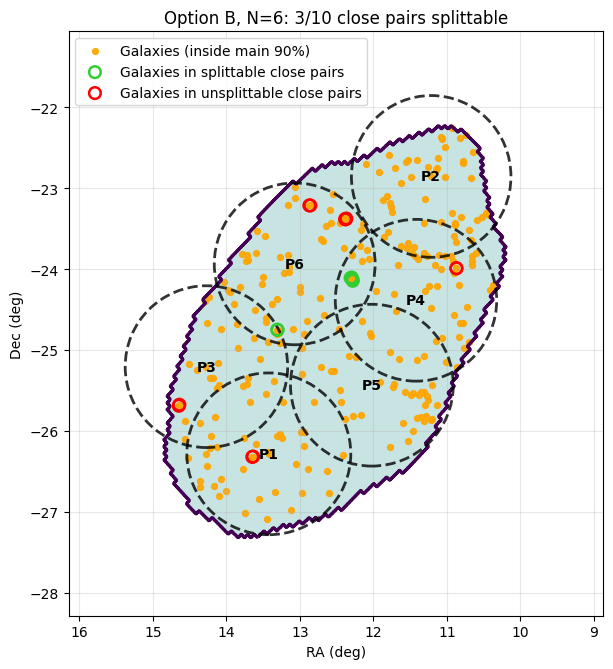

In [36]:
# ============================================================
# PLOT: 90% contour + galaxies + Option B pointings
# Highlight splittable vs non-splittable close pairs
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from astropy.coordinates import SkyCoord
import astropy.units as u

# ---------- use Option B ----------
sol = solutions[N_PLOT]
pointing_ra = np.asarray(sol["centers_ra"], dtype=float)
pointing_dec = np.asarray(sol["centers_dec"], dtype=float)

# ---------- helpers ----------
def minimal_ra_window(ra_deg, pad_deg):
    ra = np.mod(np.asarray(ra_deg, dtype=float), 360.0)
    ra_sorted = np.sort(ra)
    gaps = np.diff(np.r_[ra_sorted, ra_sorted[0] + 360.0])
    j = np.argmax(gaps)
    start = ra_sorted[(j + 1) % len(ra_sorted)]
    end = ra_sorted[j]
    return (start - pad_deg) % 360.0, (end + pad_deg) % 360.0

def ra_linspace_wrap(ra_min, ra_max, n):
    ra_min %= 360.0
    ra_max %= 360.0
    if ra_min <= ra_max:
        return np.linspace(ra_min, ra_max, n)
    a = np.linspace(ra_min, 360.0, n // 2, endpoint=False)
    b = np.linspace(0.0, ra_max, n - len(a))
    return np.r_[a, b]

def shift_ra_for_plot(x_deg, wrap):
    x = np.mod(np.asarray(x_deg, dtype=float), 360.0)
    if not wrap:
        return x
    return np.where(x > 180.0, x - 360.0, x)

# ---------- determine splittable pairs geometrically ----------
gal_coords = SkyCoord(ra=target_ra * u.deg, dec=target_dec * u.deg)
ptg_coords = SkyCoord(ra=pointing_ra * u.deg, dec=pointing_dec * u.deg)

rows = []
for _, row in collisions_df.iterrows():
    gi = int(row["target_i"])
    gj = int(row["target_j"])

    sep_i = gal_coords[gi].separation(ptg_coords).deg
    sep_j = gal_coords[gj].separation(ptg_coords).deg

    cover_i = [k + 1 for k in range(len(ptg_coords)) if sep_i[k] <= WEAVE_RADIUS_DEG]
    cover_j = [k + 1 for k in range(len(ptg_coords)) if sep_j[k] <= WEAVE_RADIUS_DEG]

    union_cover = sorted(set(cover_i) | set(cover_j))
    splittable = len(union_cover) >= 2

    rows.append({
        "target_i": gi,
        "target_j": gj,
        "sep_arcsec": row["sep_arcsec"],
        "pointings_i": cover_i,
        "pointings_j": cover_j,
        "union_pointings": union_cover,
        "splittable": splittable
    })

split_df = pd.DataFrame(rows).sort_values("sep_arcsec").reset_index(drop=True)
print(f"Splittable close pairs in Option B: {split_df['splittable'].sum()}/{len(split_df)}")
display(split_df)

# ---------- collect galaxies in splittable / unsplittable pairs ----------
splittable_gals = sorted(set(
    split_df.loc[split_df["splittable"], "target_i"].tolist() +
    split_df.loc[split_df["splittable"], "target_j"].tolist()
))
unsplittable_gals = sorted(set(
    split_df.loc[~split_df["splittable"], "target_i"].tolist() +
    split_df.loc[~split_df["splittable"], "target_j"].tolist()
))

# ---------- rebuild contour grid ----------
PAD_RA_PLOT = 1.5
PAD_DEC_PLOT = 1.2
NGRID_RA_PLOT = 2500
NGRID_DEC_PLOT = 1200

ra_min_plot, ra_max_plot = minimal_ra_window(target_ra, PAD_RA_PLOT)
dec_min_plot = float(np.min(target_dec) - PAD_DEC_PLOT)
dec_max_plot = float(np.max(target_dec) + PAD_DEC_PLOT)
wrap = ra_min_plot > ra_max_plot

ra_vals = ra_linspace_wrap(ra_min_plot, ra_max_plot, NGRID_RA_PLOT) * u.deg
dec_vals = np.linspace(dec_min_plot, dec_max_plot, NGRID_DEC_PLOT) * u.deg
RA, DEC = np.meshgrid(ra_vals, dec_vals)

grid_pix = hp_ast.lonlat_to_healpix(RA, DEC).astype(int)
Z = credible[grid_pix]

X = shift_ra_for_plot(RA.to_value(u.deg), wrap)
target_ra_plot = shift_ra_for_plot(target_ra, wrap)
pointing_ra_plot = shift_ra_for_plot(pointing_ra, wrap)

# ---------- plot ----------
fig = plt.figure(figsize=(8.8, 6.8))
ax = fig.add_subplot(111)

# 90% contour
ax.contourf(X, DEC.to_value(u.deg), Z, levels=[0.0, CREDIBLE], alpha=0.25)
ax.contour(X, DEC.to_value(u.deg), Z, levels=[CREDIBLE], linewidths=2.2, antialiased=True)

# all inside-main-island galaxies
ax.scatter(
    target_ra_plot, target_dec,
    s=18, color="orange", alpha=0.90,
    label="Galaxies (inside main 90%)"
)

# splittable pair galaxies
if splittable_gals:
    ax.scatter(
        target_ra_plot[splittable_gals],
        target_dec[splittable_gals],
        s=70, facecolors="none", edgecolors="limegreen",
        linewidths=1.8, zorder=6,
        label="Galaxies in splittable close pairs"
    )

# unsplittable pair galaxies
if unsplittable_gals:
    ax.scatter(
        target_ra_plot[unsplittable_gals],
        target_dec[unsplittable_gals],
        s=70, facecolors="none", edgecolors="red",
        linewidths=1.8, zorder=6,
        label="Galaxies in unsplittable close pairs"
    )

# WEAVE fields
for i, (ra0, dec0) in enumerate(zip(pointing_ra_plot, pointing_dec), start=1):
    cosd = np.cos(np.deg2rad(dec0))
    width = 2.0 * WEAVE_RADIUS_DEG / max(cosd, 1e-6)
    height = 2.0 * WEAVE_RADIUS_DEG
    e = Ellipse(
        (ra0, dec0),
        width=width,
        height=height,
        fill=False,
        linestyle="--",
        linewidth=2,
        alpha=0.8,
        zorder=5
    )
    ax.add_patch(e)
    ax.text(ra0, dec0, f"P{i}", ha="center", va="center",
            fontsize=10, weight="bold", zorder=7)

# axes
if wrap:
    ra_min_s = shift_ra_for_plot([ra_min_plot], True)[0]
    ra_max_s = shift_ra_for_plot([ra_max_plot], True)[0]
    ax.set_xlim(ra_max_s, ra_min_s)
else:
    ax.set_xlim(ra_max_plot, ra_min_plot)

ax.set_ylim(dec_min_plot, dec_max_plot)
ax.set_xlabel("RA (deg)")
ax.set_ylabel("Dec (deg)")
ax.set_title(
    f"Option B, N={N_PLOT}: {split_df['splittable'].sum()}/{len(split_df)} close pairs splittable"
)
ax.grid(True, alpha=0.3)
ax.legend(loc="best")

dec0 = 0.5 * (dec_min_plot + dec_max_plot)
ax.set_aspect(1.0 / np.cos(np.deg2rad(dec0)), adjustable="box")

plt.tight_layout()
plt.show()